# Quantitative Pairs Trading & Statistical Arbitrage Strategy
---


## Executive sumary

In this project we implement a quantitative machine learning pipeline to forecast the daily price spread dynamics between the two highly correlated assets: Visa (V) and Mastercard (MA), 

We combine classical statistical testing (cointegration and mean-reversion) with time-series feature engineering and gradient boosting models.

## Business & Consulting Context

Below are listed some of the important factors in analysing relative business valuations:

* **Statistical Artbirtage:** Markets are largely efficient in predicting absolute directional movement, but relative pricing discrepancies between industry peers often temporarily diverge due to market noise or asymmetric order flows.

* **Competitor Dynamics:** Visa and Mastercard share nearly identical macroeconomic drivers, regulatory environments, and business models. When their relative valuation spreads diverge beyond the norm, statistical models can identify mean-reversion opportunities

## Project Objectives

1. **Data Pipeline & Analysis:** Extract and clean 5 years of daily market price data using: *yfinance and pandas*

2. **Statistical Validation:** Formally test for long-term equilibrium and stationarity using the **Engle-Granger Cointegration** Test and the **Augmented Dickey-Fuller (ADF) Test**

3. **Feature Engineering:** Construct rolling technical indicators, statistical metrics (Z-scores), and temporal lag features without introducing forward-loowking data leakage

4. **Machine Learning and Time-Series Cross-Validation:** Train regression Models (Baseline Linear Regression and XGBoost Regressor) usign strict time-series split validation (*TimeSeriesSplit*) to predict next-day spread targets

5. **Strategy Simulation:** Translate continuous model outputs into actionable mean-reversion trade triggers and document evaluation metrics (MAE, RMSE, R^2)

## Technical Stack and Tools

* **Language:** Python 
* **Data Extraction & Manipulation:** yfinance, pandas, numpy
* **Statistical Modelling:** statsmodels, scipy
* **Machine Learning:** scikit-learn, xgboost
* **Data visualisation:** matplotlib, seaborn

---

# Phase 1: Data Acquisition & Exploratory Data Analysis

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint
%matplotlib inline

# Setting up visual style
plt.style.use('dark_background')

We wil now pull clean historical market data gor two asset pairs and perform EDA

In [2]:
def run_phase_1(ticker1 = 'V', ticker2 = 'MA', start_date = '2019-01-01', end_date = '2024-01-01'):

    # 1. Pulling Historical Data using yfinance

    print(f"\n[1/4] Pulling data from {start_date} to {end_date}...")
    tickers = [ticker1, ticker2]
    raw_data = yf.download(tickers, start=start_date, end = end_date)['Close']

    # 2. Inspect and clean the data

    print(f"\n[2/4] Inspecting data quality...")

    print(f"Raw Shape: {raw_data.shape}")

    missing_count = raw_data.isnull().sum()
    print(f"Missing values per ticker:\n{missing_count}")

    # Forward filling missing values and dropping remaining NAs
    clean_data = raw_data.ffill().dropna()
    print(f"Cleaned shape: {clean_data.shape}")

    # Extract indicidual prices series
    price_a = clean_data[ticker1]
    price_b = clean_data[ticker2]

    # 3. Exploratory Data Analysis Metrics
    print(f"\n[3/4] Calculating core statistical metrics...")

    # Daily Returns
    returns_a = price_a.pct_change().dropna()
    returns_b = price_b.pct_change().dropna()

    # Correlation Analysis
    price_corr = price_a.corr(price_b)
    returns_corr = returns_a.corr(returns_b)

    print(f"-> Price Correlation ({ticker1} vs {ticker2}): {price_corr:.4f}")
    print(f"-> Returns Correlation ({ticker1} vs {ticker2}): {returns_corr:.4f}")

    # Normalised Prices (Base = 100 at start of period)
    norm_a = (price_a / price_a.iloc[0]) * 100
    norm_b = (price_b / price_b.iloc[0]) * 100

    # Raw Unhedged Spread
    raw_spread = price_a - price_b
    print(f"-> Mean Raw Spread: ${raw_spread.mean():.2f}")
    print(f"-> Spread Std Dev: ${raw_spread.std():.2f}")

    # 4. Visualization Plots
    print(f"\n[4/4] Generating EDA Visualizations...")
    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=False)
    bg_color = '#1e1e1e'  # VS Code editor dark grey background
    panel_color = '#252526'  # VS Code panel grey
    grid_color = '#383838'   # Subtle grid lines

    fig.patch.set_facecolor(bg_color)

    for ax in axes:
        ax.set_facecolor(bg_color)
        ax.grid(True, color=grid_color, linestyle='--', alpha=0.7)

    # Plot 1: Normalized Price Paths (Neon Green & Pink)
    axes[0].plot(norm_a.index, norm_a, label=f"{ticker1} (Normalized)", color='#00ff66', linewidth=1.8)
    axes[0].plot(norm_b.index, norm_b, label=f"{ticker2} (Normalized)", color='#ff007f', linewidth=1.8)
    axes[0].set_title(f"1. Normalized Price Trajectories (Base = 100) | Corr: {price_corr:.2f}", fontsize=12, fontweight='bold', color='#ffffff')
    axes[0].set_ylabel("Normalized Value ($)", color='#e0e0e0')
    axes[0].legend(loc='upper left', facecolor=panel_color, edgecolor='#3c3c3c')

    # Plot 2: Scatter Plot of Returns (Neon Green Scatter + Neon Pink Fit Line)
    sns.regplot(x=returns_a, y=returns_b, ax=axes[1], 
                scatter_kws={'alpha':0.5, 's':15, 'color':'#00ff66'}, 
                line_kws={'color':'#ff007f', 'linewidth':2})
    axes[1].set_title(f"2. Daily Returns Scatter & Linear Fit | Corr: {returns_corr:.2f}", fontsize=12, fontweight='bold', color='#ffffff')
    axes[1].set_xlabel(f"{ticker1} Daily Return", color='#e0e0e0')
    axes[1].set_ylabel(f"{ticker2} Daily Return", color='#e0e0e0')

    # Plot 3: Raw Price Spread over Time (Electric Cyan Line & Pink Mean Band)
    axes[2].plot(raw_spread.index, raw_spread, color='#00e5ff', linewidth=1.4, label='Raw Spread (Price A - Price B)')
    axes[2].axhline(raw_spread.mean(), color='#ff007f', linestyle='--', linewidth=1.5, label=f'Mean Spread (${raw_spread.mean():.2f})')
    axes[2].fill_between(raw_spread.index, raw_spread.mean() - raw_spread.std(), raw_spread.mean() + raw_spread.std(), 
                         color='#ff007f', alpha=0.15, label='±1 Std Dev Band')
    axes[2].set_title(f"3. Raw Unhedged Price Spread ({ticker1} - {ticker2})", fontsize=12, fontweight='bold', color='#ffffff')
    axes[2].set_ylabel("Price Difference ($)", color='#e0e0e0')
    axes[2].set_xlabel("Date", color='#e0e0e0')
    axes[2].legend(loc='upper left', facecolor=panel_color, edgecolor='#3c3c3c')

    plt.tight_layout()
    plt.show()

    return clean_data




[1/4] Pulling data from 2019-01-01 to 2024-01-01...


[*********************100%***********************]  2 of 2 completed



[2/4] Inspecting data quality...
Raw Shape: (1258, 2)
Missing values per ticker:
Ticker
MA    0
V     0
dtype: int64
Cleaned shape: (1258, 2)

[3/4] Calculating core statistical metrics...
-> Price Correlation (V vs MA): 0.9821
-> Returns Correlation (V vs MA): 0.9135
-> Mean Raw Spread: $-122.78
-> Spread Std Dev: $24.69

[4/4] Generating EDA Visualizations...


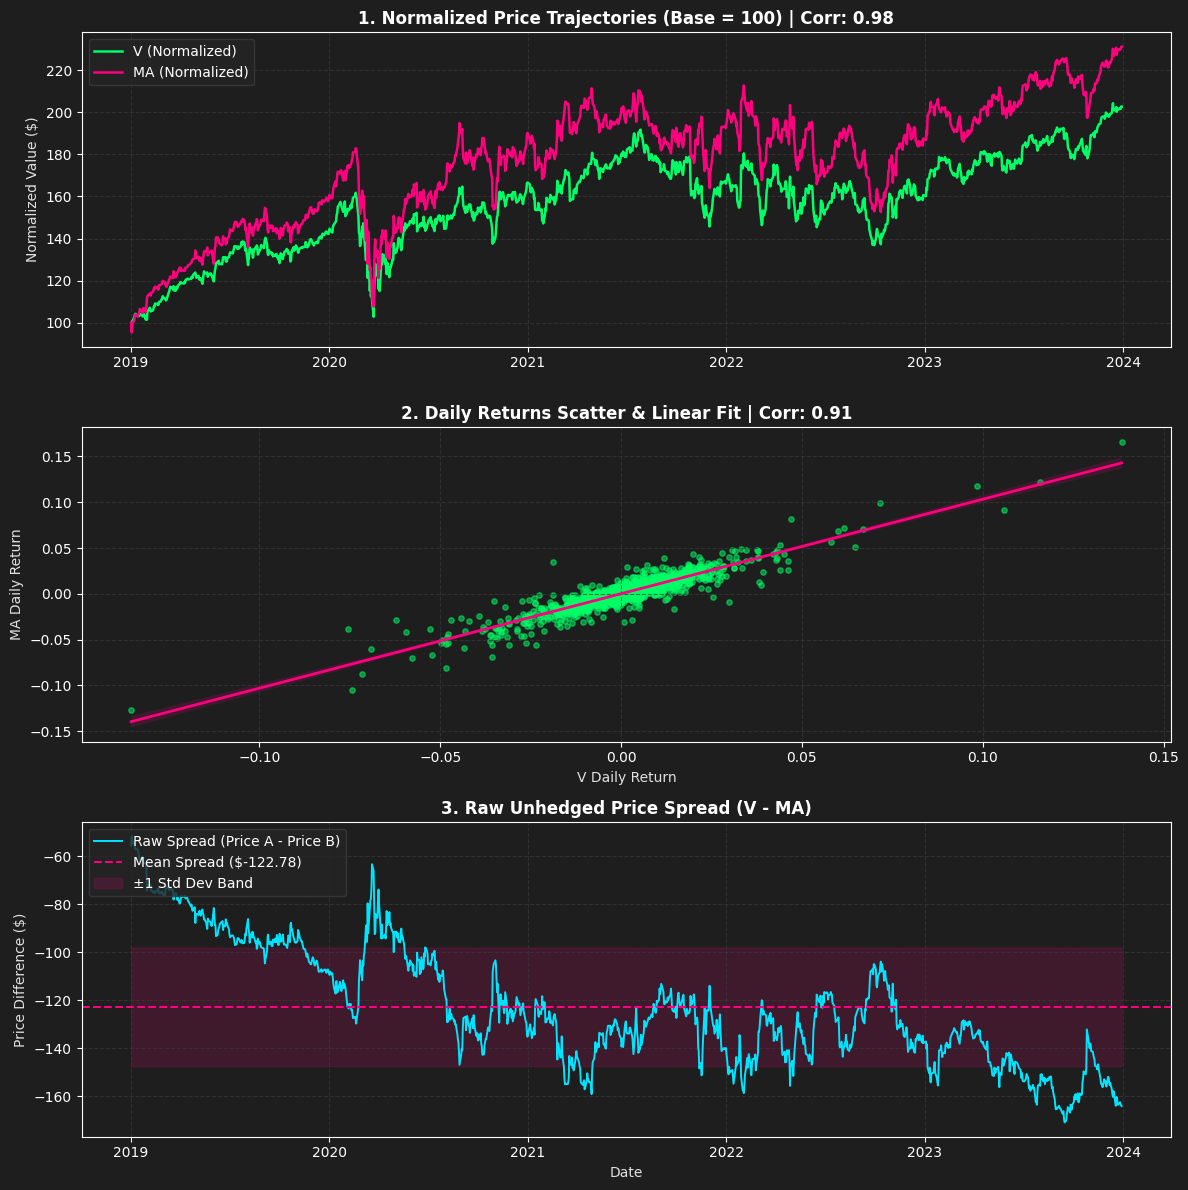

In [3]:
df = run_phase_1(ticker1='V', ticker2 = 'MA', start_date='2019-01-01', end_date='2024-01-01')

So far we have extracted, cleaned and analysed 5 years of daily market price data (2019-2024) for the publicly traded stocks of: **Visa Inc. (`V`)** and **Mastercard Incorporated (`MA`)**

Plot analysis:

1. **Normalized Price Trajectories (Plot 1):**
    When both stock prices are normalized to a starting baseline of $100 in 2019, we observe near-identical long-term price co-movement. This visual tracking is supported by an extremely high Pearson correlation coefficient of 0.9821, confirming shared long-term macroeconomic growth drivers.    

2. **Daily Returns Coupling (Plot 2):**
    The scatter plot of daily percentage returns reveals a tight distribution along the linear fit line, yielding a high correlation of 0.9135. This proves strong short-term statistical coupling, indicating that daily market shocks impact both payment networks symmetrically.

3. **Unhedged Price Spread Drift (Plot 3):**
    Plotting the raw dollar difference ($\text{Visa} - \text{Mastercard}$) reveals an overall downward trajectory over time rather than a stationary mean-reverting path. Because Mastercard trades at a higher absolute per-share price, proportional percentage growth causes the raw dollar gap to widen over the 5-year window (moving from roughly $-\$60$ down toward $-\$160$).

When we increase the lookback window from 5 to 15 years we observe a massive divergence in the normalised price trajectories of Mastercard and Visa. This is because small annual differences compound into massie gaps over a 15-year horizon. This will be managed in Phase 2.


[1/4] Pulling data from 2009-01-01 to 2024-01-01...


[*********************100%***********************]  2 of 2 completed



[2/4] Inspecting data quality...
Raw Shape: (3774, 2)
Missing values per ticker:
Ticker
MA    0
V     0
dtype: int64
Cleaned shape: (3774, 2)

[3/4] Calculating core statistical metrics...
-> Price Correlation (V vs MA): 0.9963
-> Returns Correlation (V vs MA): 0.8370
-> Mean Raw Spread: $-53.47
-> Spread Std Dev: $52.62

[4/4] Generating EDA Visualizations...


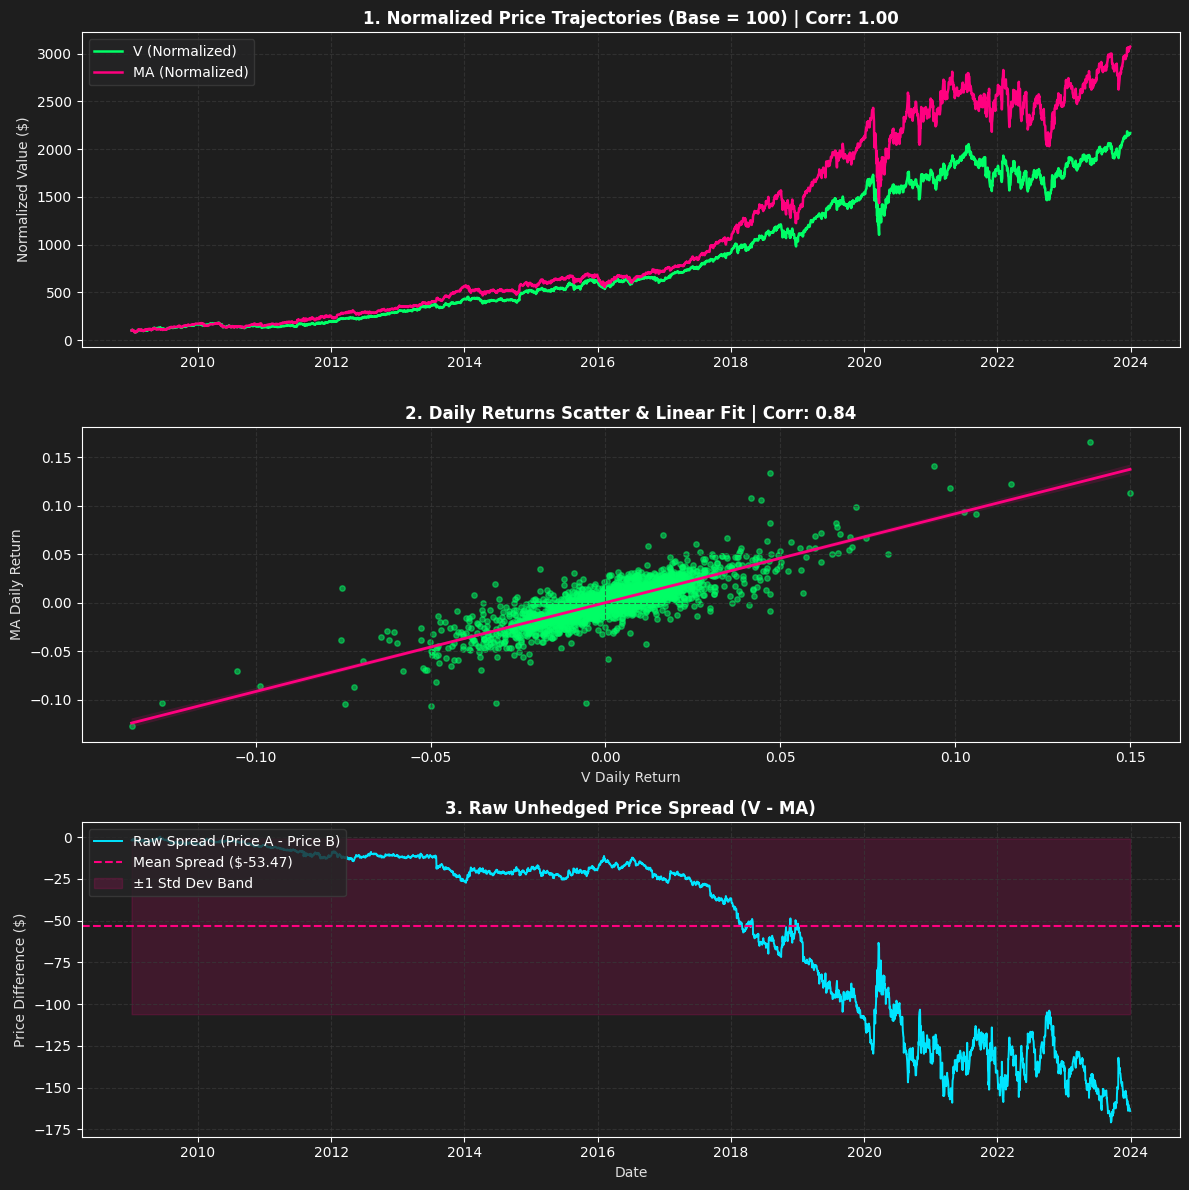

In [4]:
df = run_phase_1(ticker1='V', ticker2 = 'MA', start_date='2009-01-01', end_date='2024-01-01')

## Deep Dive: Why Cointegration Fails Across Non-Symmetric Pairs

# A. The Extreme Case: Visa (V) vs. PayPal (PYPL) — Structural Decoupling

What the Results Show: While daily returns still show a moderate correlation ($0.5564$), the price correlation collapses to $0.1416$. The raw spread plot shows a severe, multi-year trend where the price gap moves from $-\$100$ in 2021 to over $+\$150$ in 2023.

Why it Breaks Down: Post-2021, PayPal suffered from compression in transaction margins, intense competition from Apple Pay/Shopify, and slowing user acquisition. Meanwhile, Visa’s global cross-border volume expanded.

Quant Arbitrage Takeaway: Trying to pairs-trade V vs. PYPL using mean reversion would result in catastrophic losses (a "value trap"). The spread never reverts to its mean because the underlying businesses underwent a fundamental regime shift.

# B. The Credit Risk Case: Visa (V) vs. American Express (AXP) — Balance Sheet Asymmetry

What the Results Show: A respectable price correlation ($0.7807$) and returns correlation ($0.7147$). However, in Plot 1 during the March 2020 market crash, AXP dropped significantly deeper than V and took much longer to recover.

Why it Breaks Down: Visa is an open-loop network that does not issue loans or hold debt; it simply collects a toll on payment processing. American Express is a closed-loop bank issuer that carries consumer credit card debt on its balance sheet.

Quant Arbitrage Takeaway: During economic downturns, AXP must increase credit loss reserves to prepare for consumer loan defaults, dragging down its stock price independently of transaction volumes. This balance-sheet risk destroys long-term spread stationarity.

# C. The Sector Case: Visa (V) vs. JPMorgan Chase (JPM) — Macro vs. Business Model Divergence

What the Results Show: A high price correlation ($0.8250$), but a lower daily returns correlation ($0.6229$).

Why it Breaks Down: Both companies benefit from broad economic growth and consumer spending. However, JPMorgan’s profitability is tied to Net Interest Income (NII), Federal Reserve interest rate cycles, and investment banking deal flow, whereas Visa acts as an inflation-hedged tech network.

Quant Arbitrage Takeaway: The spread moves in wide macro cycles rather than rapid, mean-reverting oscillations, making short-term statistical arbitrage unreliable.

# The Cointegration Imperative: Why V and MA Win

For two time-series $P_{A,t}$ and $P_{B,t}$ to be cointegrating, a linear combination must exist:

$$\text{Spread}_t = P_{A,t} - \gamma \cdot P_{B,t} \sim I(0)$$

where $\text{Spread}_t$ is integrated of order zero $I(0)$, meaning it possesses a constant mean, constant variance, and zero long-term drift.

Because Visa and Mastercard share:

Identical Business Models: Both earn percentage fees on transaction volume without taking credit default risk.

Symmetric Macro Drivers: Inflation increases nominal basket sizes for both networks equally.

Dual Market Dominance: Regulatory changes impact both entities almost identically.

Their price relationship minimizes firm-specific regime noise, creating the perfect candidate pair for Phase 2: Hedge Ratio Optimization & Engle-Granger Cointegration Testing.


[1/4] Pulling data from 2019-01-01 to 2024-01-01...


[*********************100%***********************]  2 of 2 completed



[2/4] Inspecting data quality...
Raw Shape: (1258, 2)
Missing values per ticker:
Ticker
PYPL    0
V       0
dtype: int64
Cleaned shape: (1258, 2)

[3/4] Calculating core statistical metrics...
-> Price Correlation (V vs PYPL): 0.1416
-> Returns Correlation (V vs PYPL): 0.5564
-> Mean Raw Spread: $61.77
-> Spread Std Dev: $72.33

[4/4] Generating EDA Visualizations...


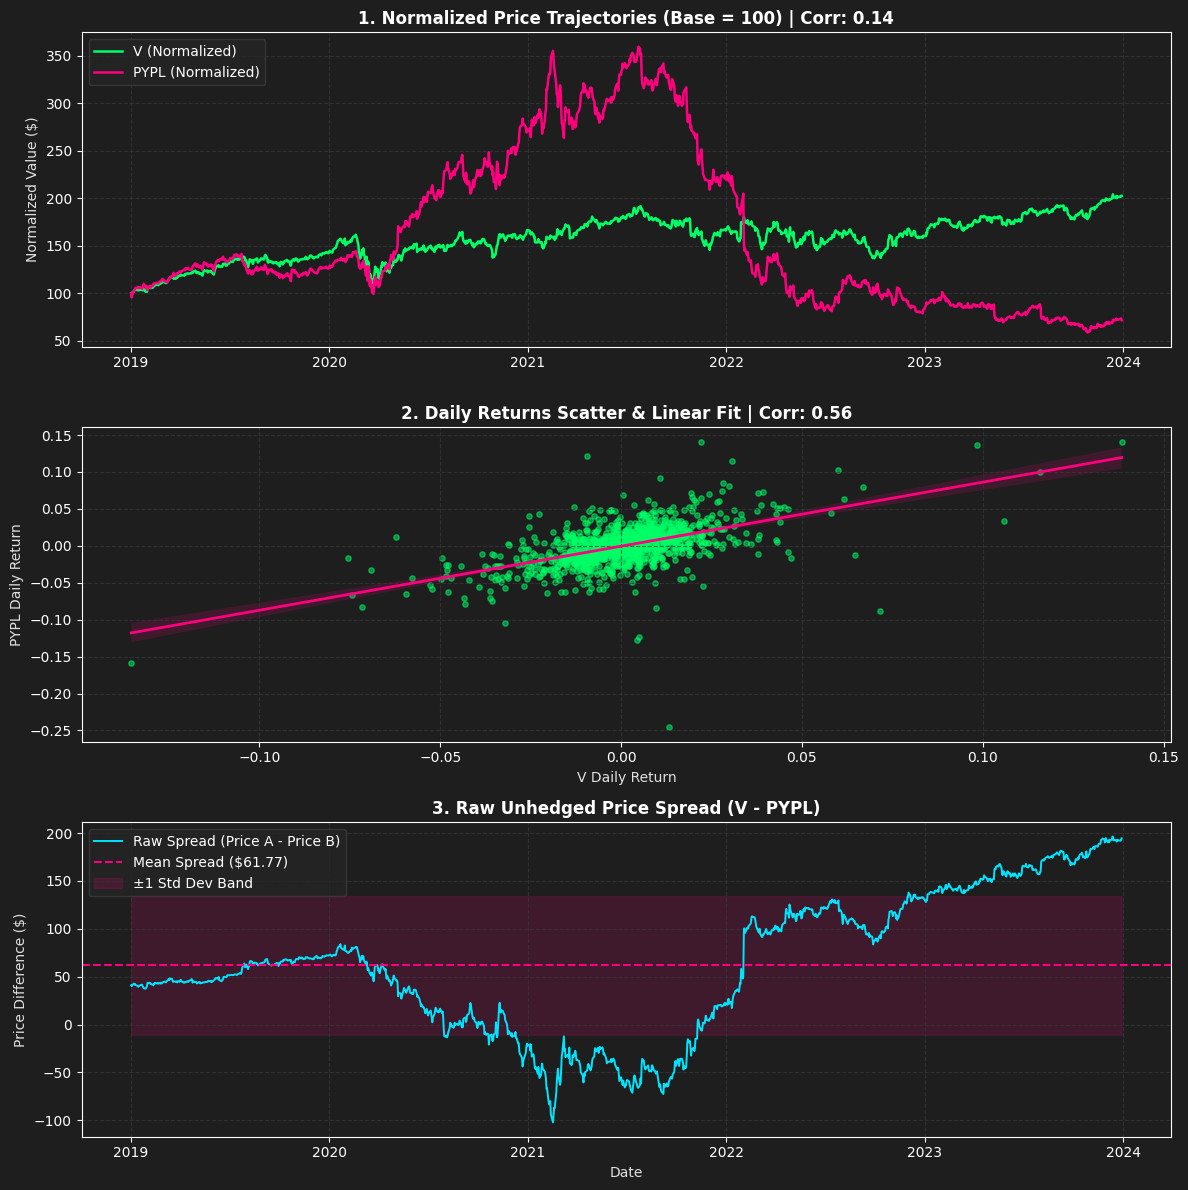

In [5]:
df = run_phase_1(ticker1='V', ticker2 = 'PYPL', start_date='2019-01-01', end_date='2024-01-01')


[1/4] Pulling data from 2019-01-01 to 2024-01-01...


[*********************100%***********************]  2 of 2 completed



[2/4] Inspecting data quality...
Raw Shape: (1258, 2)
Missing values per ticker:
Ticker
AXP    0
V      0
dtype: int64
Cleaned shape: (1258, 2)

[3/4] Calculating core statistical metrics...
-> Price Correlation (V vs AXP): 0.7787
-> Returns Correlation (V vs AXP): 0.7147
-> Mean Raw Spread: $65.69
-> Spread Std Dev: $18.73

[4/4] Generating EDA Visualizations...


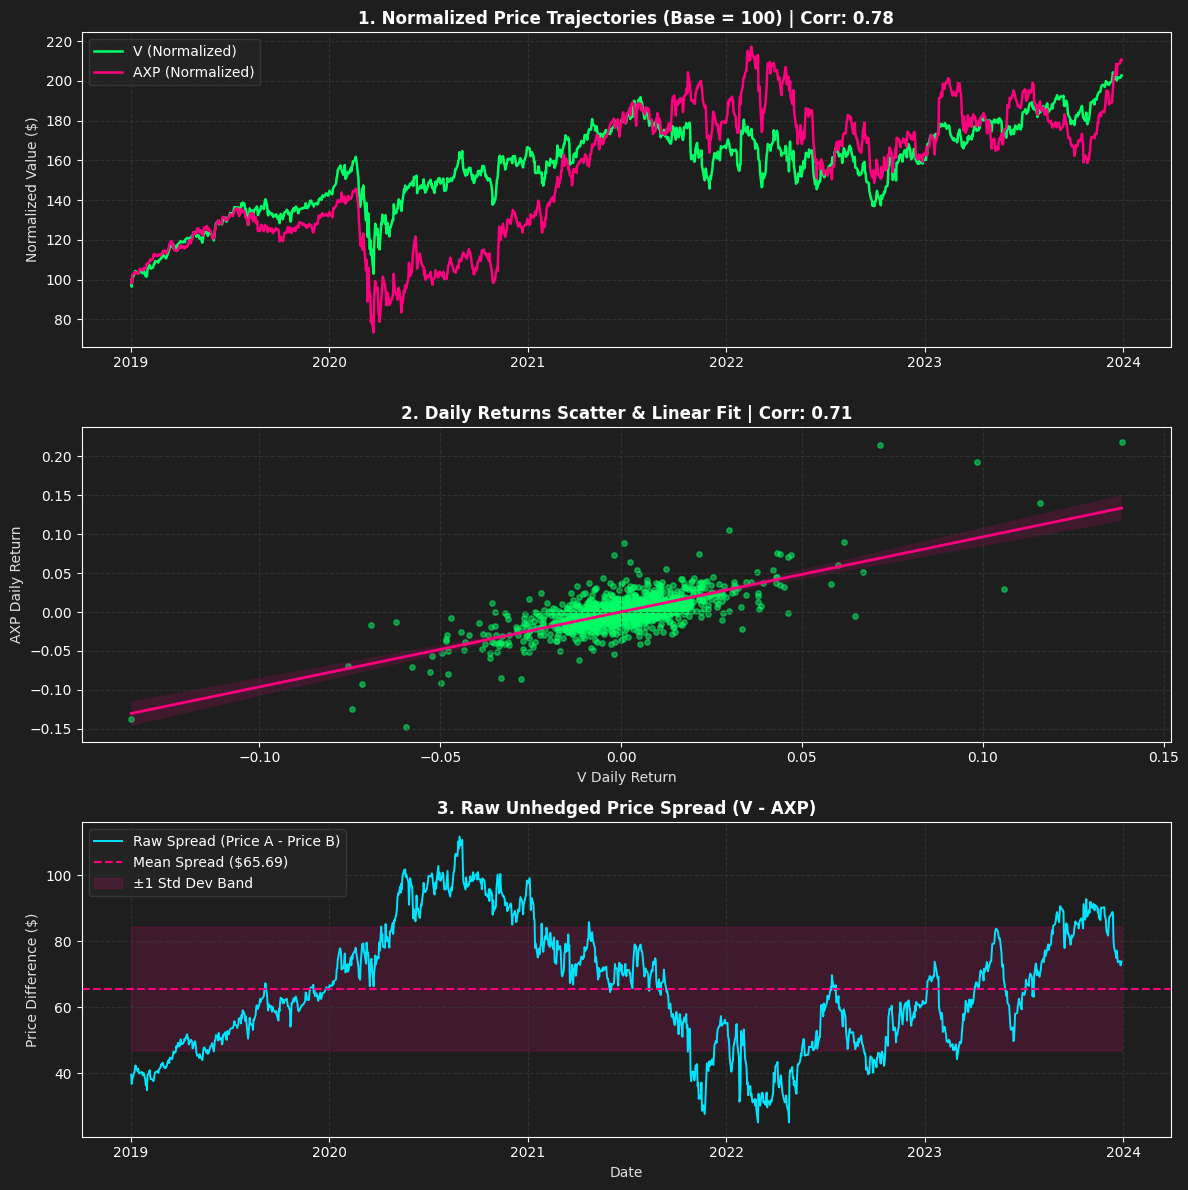

In [6]:
df = run_phase_1(ticker1='V', ticker2 = 'AXP', start_date='2019-01-01', end_date='2024-01-01')


[1/4] Pulling data from 2019-01-01 to 2024-01-01...


[*********************100%***********************]  2 of 2 completed



[2/4] Inspecting data quality...
Raw Shape: (1258, 2)
Missing values per ticker:
Ticker
JPM    0
V      0
dtype: int64
Cleaned shape: (1258, 2)

[3/4] Calculating core statistical metrics...
-> Price Correlation (V vs JPM): 0.8250
-> Returns Correlation (V vs JPM): 0.6229
-> Mean Raw Spread: $83.31
-> Spread Std Dev: $15.58

[4/4] Generating EDA Visualizations...


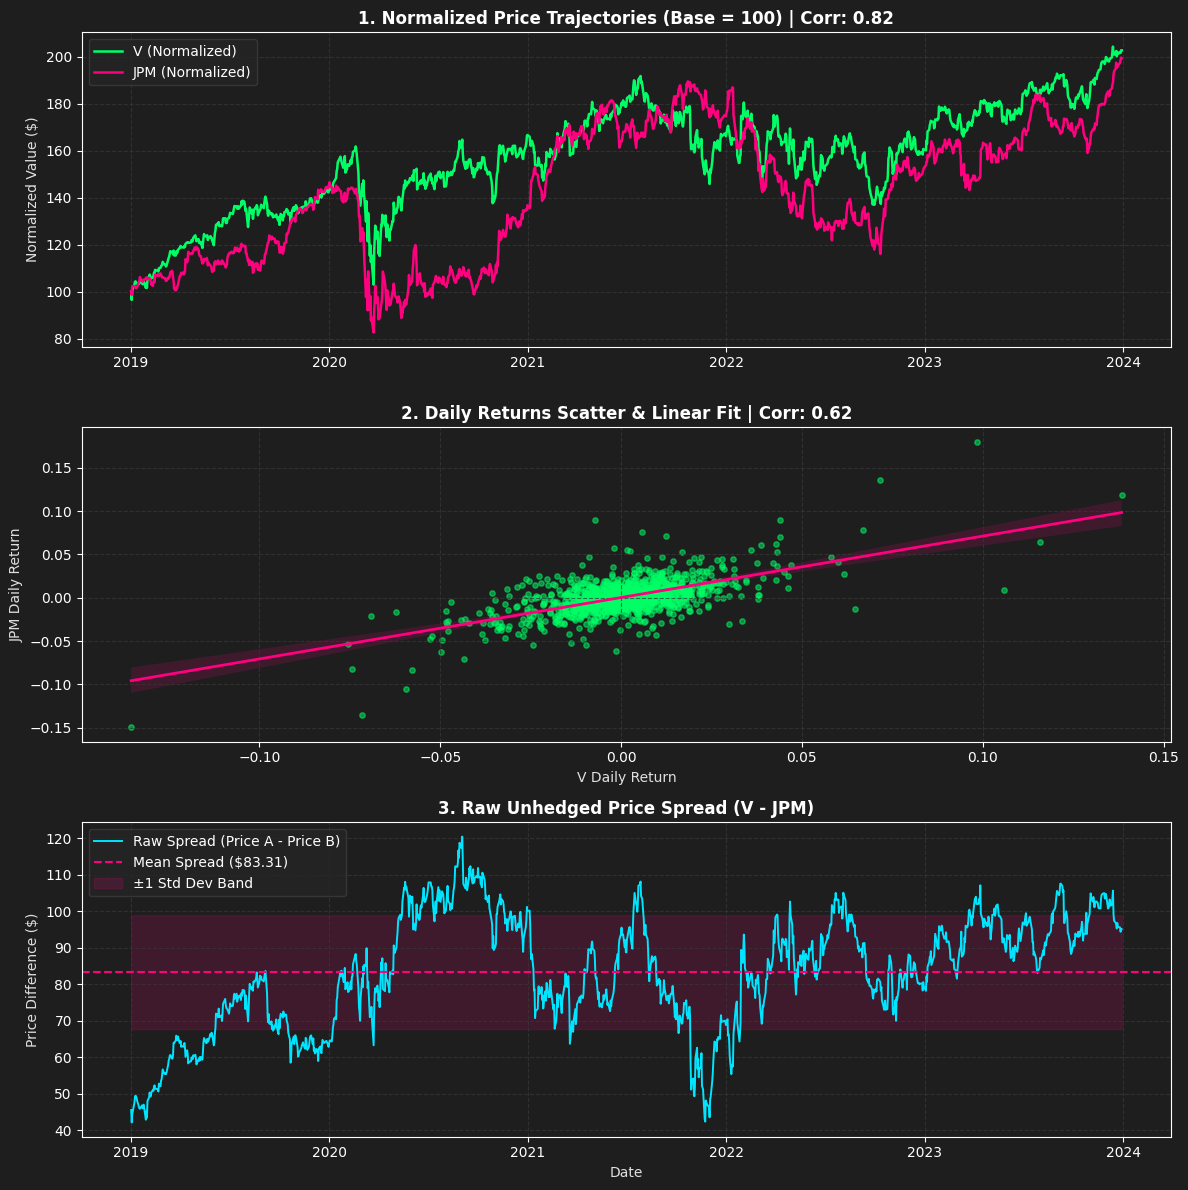

In [7]:
df = run_phase_1(ticker1='V', ticker2 = 'JPM', start_date='2019-01-01', end_date='2024-01-01')

---

# Phase 2: Statistical Foundation - Cointegration & Stationarity

In statistical arbitrage, visually observing that two stocks move together is insufficient for deploying capital. We must mathematically prove that their relationship is stable over time and that any divergence will reliably revert to a mean. This phase focuses on teh core statistical tests used to validate the Visa(`V`) and Mastercard (`MA`) pair

## 1. What does "Cointegrated" mean?

**Correlation** measures how two variables move in relation to each otehr in the short term. However, two highly correlated series can still drift apart indefinitely over time.

**Cointegration** is a stricter mathematical property. Two time series are cointegrated if they share a long-term equilibrium. Even if they wander apart randomly in the short term, an underlying property pulls them back together. Precisely, two non-stationary price series are cointegrated if a linear combination of them results in a stationary series (a series with a constant mean and variance).


## 2. What is an OLS Regression:

**Ordinary Least Squares (OLS) Regression**  is a statistical method used to find the line of best fit through a scatter plot of data points.

In our context, we plot the price of Mastercard on the X-axis and the price of Visa on the Y-axis. OLS calculates the straight line that minimises the sum of the squared vertical distances (the "errors" or "residuals") between the actual data points and the line itself. 

The equation of this line is: $\text{Price}_V = \gamma \cdot \text{Price}_{MA} + \text{Intercept} + \text{Error}$

The slope of this OLS regression line is critical - it becomes our Hedge Ratio

## How the Hedge Ratio ($\gamma$) works

The **Hedge Ratio ($\gamma$)**, derived from the slop of the OLS regression, tells us exactly how to balance our portfolio to neutralise market risk and isolate the spread.

Instaed of a naive 1:1 subtraction ($\text{Price}_V - \text{Price}_{MA}$), which we saw causes long-term drigt, we construct a Hedged Spread: $$\text{Hedged Spread} = \text{Price}_V - (\gamma \cdot \text{Price}_{MA})$$ If our OLS regression outputs a $\gamma$ of 0.65, the interpretation is:


*"To maintain a market-neutral position, for every 1 share of Visa we buy (Long), we must short-sell 0.65 shares of Mastercard."*

By weighting the assets according to this ratio, we mathematically eliminate the structural growth differences, resulting in a flat, tradable spread.

## 4. What is the Augmented Dickey-Fuller (ADF) Test?

Once we create out Hedged Spread, we must prove it is stationary (meaning it predictably oscillates around a constant mean and doesn't drift to infinity).

The **Augmented Dickey-Fuller (ADF)** test checks for the presence of a "unit root" in the time series:

* **Null Hypothesis ($H_0$):** The series has a unit root (it is non-stationary and unpredictable)
* **Alternative Hypothese ($H_1$):** The series has no unit root (it is stationary and mean-reverting)

*The Underlying Mathematics of the ADF Test*

Imagine a simple time series where today's price ($y_t$) depends on yesterday's price ($y_{t-1}$) plus some random noise ($\epsilon_t$):
$$y_t = \rho y_{t-1} + \epsilon_t$$

* if $\rho = 1$, the series is a random walk.
* if $\rho <1$, the series is Stationary (mean-reverting).

To test this subtract $y_{t-1}$ from both sides.

$$\Delta y_t = (\rho - 1)y_{t-1} + \epsilon_t$$

Define $\gamma = (\rho -1)$


Financial data usually has momentum. To account for this, we "augment" the equation by adding lagged changes ($\Delta y_{t-i}) and constant terms:



$$\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^{p} \delta_i \Delta y_{t-i} + \epsilon_t$$

Now we run an OLS regression on this equation to find the values of $\gamma$.

Once the regression calculates an estimate for $\hat{\gamma}$, it calculates a t-statistic:

$$\text{ADF Statistic} = \frac{\hat{\gamma}}{\text{Standard Error}(\hat{\gamma})}$$

However, David Dickey and Wayne Fuller mathematically proved that if the data has a unit root, the test statistic does not follow a normal bell curve. It follows a skewed, custom distribution (the Dickey-Fuller distribution).

## 5. What the Engle-Granger Cointegration Test Does

While the ADF test is run on the spread, the **Engle-Granger test** is designed specifically to test the relationship between the two original price series:

It is a two-step process that essentially automates what we just did:

1. It runs the OLS regression between the two non-stationary price series to find the residualts (the errors/spread)
2. It automatically applies the ADF test to those specific residuals

In [8]:
def run_phase_2(ticker1='V', ticker2='MA', start_date = '2019-01-01', end_date = '2024-01-01'):

    print(f"\n[1/4] Fetching data from {ticker1} vs {ticker2}...")
    
    data = yf.download([ticker1, ticker2], start = start_date, end = end_date)['Close']
    data = data.ffill().dropna()

    price_a = data[ticker1]
    price_b = data[ticker2]

    print(f"\n[2/4] Running OLS Regression to calculate Hedge Ratio...")

    # We add a constant to Assetr B's price to account for the intercept in the regression
    X = sm.add_constant(price_b)
    y = price_a

    # Fit the Ordinary Least Squares (OLS) model
    ols_model = sm.OLS(y, X).fit()

    # The coefficient of Asset B is our Hedge Ratio
    hedge_ratio = ols_model.params[ticker2]
    intercept = ols_model.params['const']

    print(f" -> Optimal Hedge Ratio (gamma): {hedge_ratio:.4f}")
    print(f" -> Meaning: For every 1 share of {ticker1}, we short {hedge_ratio:.4f} shares of {ticker2}.")

    print(f"\n [3/4] Calculating Hedged Spread and testing stationarity...")
    # Formula: Spread = Price_A - (Hedge_Ratio * Price_B)
    hedged_spread = price_a - (hedge_ratio * price_b)

    # 1. Augmented Dickey-Fuller (ADF) Test on the Hedged Spread
    adf_result = adfuller(hedged_spread)
    adf_statistic = adf_result[0]
    adf_pvalue = adf_result[1]

    # 2. Engle-Granger Cointegration Test (Directly tests the two price series)
    coint_stat, coint_pvalue, _ = coint(price_a, price_b)

    print(f"-> ADF test p-value: {adf_pvalue:.4f}")
    print(f"-> Engle-Granger p-value: {coint_pvalue:.4f}")

    if adf_pvalue < 0.05 and coint_pvalue < 0.05:
        print("\n=> CONCLUSION: The spread is STATIONARY. The assets are highly cointegrated!. Proceed to ML Phase.")
    else:
        print("\n=> CONCLUSION: The spread is NON-STATIONARY. These assets are not cointegrated.")

    print(f"\n[4/4] Generating Phase 2 Visualisations...")

    plt.style.use('dark_background')
    bg_color = '#1e1e1e'
    panel_color = '#252526'
    grid_color = '#383838'


    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    fig.patch.set_facecolor(bg_color)

    for ax in axes:
        ax.set_facecolor(bg_color)
        ax.grid(True, color=grid_color, linestyle='--', alpha=0.7)

    # Plot 1: Scatter plot of Prices with OLS Regression Line
    axes[0].scatter(price_b, price_a, alpha=0.5, color='#00ff66', s=10, label='Daily Prices')
    
    # Generate points for the regression line
    x_vals = np.linspace(price_b.min(), price_b.max(), 100)
    y_vals = intercept + hedge_ratio * x_vals
    axes[0].plot(x_vals, y_vals, color='#ff007f', linewidth=2.5, 
                 label=f'OLS Fit (Slope / Hedge Ratio = {hedge_ratio:.2f})')
    
    axes[0].set_title(f"1. OLS Regression: {ticker1} vs {ticker2} Prices", fontsize=12, fontweight='bold', color='white')
    axes[0].set_xlabel(f"{ticker2} Price ($)", color='#e0e0e0')
    axes[0].set_ylabel(f"{ticker1} Price ($)", color='#e0e0e0')
    axes[0].legend(loc='upper left', facecolor=panel_color, edgecolor='#3c3c3c')

    # Plot 2: The Stationary Hedged Spread
    axes[1].plot(hedged_spread.index, hedged_spread, color='#00e5ff', linewidth=1.5, label='Hedged Spread')
    axes[1].axhline(hedged_spread.mean(), color='#ff007f', linestyle='--', linewidth=2, label=f'Mean ({hedged_spread.mean():.2f})')
    axes[1].fill_between(hedged_spread.index, 
                         hedged_spread.mean() - hedged_spread.std(), 
                         hedged_spread.mean() + hedged_spread.std(), 
                         color='#ff007f', alpha=0.15, label='±1 Std Dev')
    
    axes[1].set_title(f"2. Hedged Spread | ADF p-value: {adf_pvalue:.4f} (Stationary)", fontsize=12, fontweight='bold', color='white')
    axes[1].set_xlabel("Date", color='#e0e0e0')
    axes[1].set_ylabel("Hedged Spread ($)", color='#e0e0e0')
    axes[1].legend(loc='upper left', facecolor=panel_color, edgecolor='#3c3c3c')

    plt.tight_layout()
    plt.show()

    return data, hedged_spread
    

[*********************100%***********************]  2 of 2 completed


[1/4] Fetching data from V vs MA...

[2/4] Running OLS Regression to calculate Hedge Ratio...
 -> Optimal Hedge Ratio (gamma): 0.5285
 -> Meaning: For every 1 share of V, we short 0.5285 shares of MA.

 [3/4] Calculating Hedged Spread and testing stationarity...


-> ADF test p-value: 0.0016
-> Engle-Granger p-value: 0.0078

=> CONCLUSION: The spread is STATIONARY. The assets are highly cointegrated!. Proceed to ML Phase.

[4/4] Generating Phase 2 Visualisations...


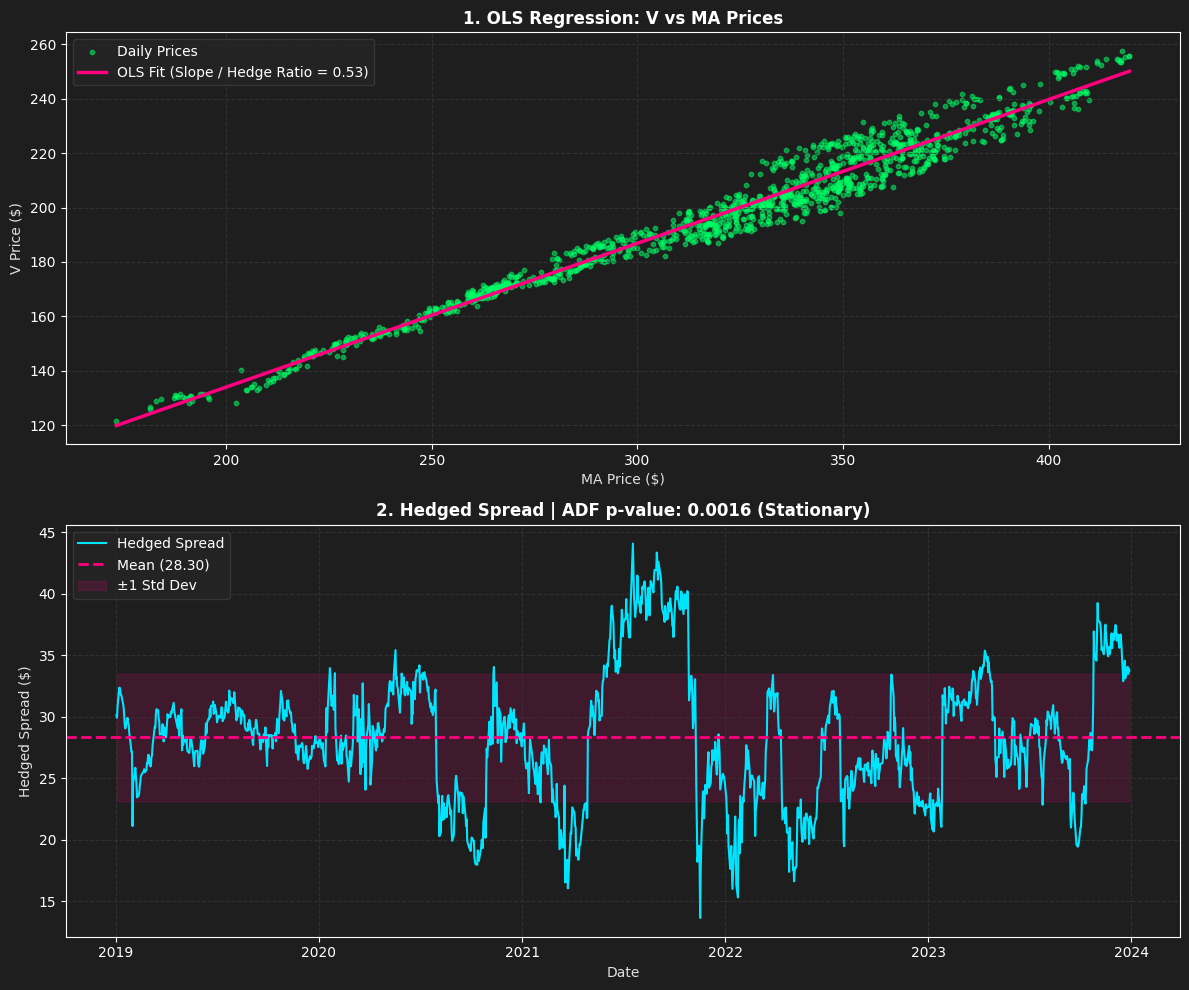

In [9]:
df, spread = run_phase_2(ticker1='V', ticker2='MA', start_date='2019-01-01', end_date='2024-01-01')

## Result analysis

* Plot 1: We see that the data remains highly correlated and have found the hedge ratio to be $\gamma = 0.53$

* Once we find the hedge spread ($\text{Hedged Spread} = \text{Price}_V - (0.5285 \cdot \text{Price}_{MA})$), we observe that the new spread oscillates horizontally around a constant mean of $28.30. It no longer drigts as we saw in spreads previously. 

We obtained p-values:

* ADF p-value: 0.0016
* Engle-Granger p-value: 0.0078

Because both are strictly <0.05, we confidently reject $H_0$ in favour of $H_1$. The spread is to be considered stationary and cointegrated.




## Why a 5 year horizon?

I wanted to look further into why we choose 5 years as the horizon.

When we run the OLS over 15-years of data for example, it calculates a single, static Hedge Ratio ($\gamma$). Because of the shifting business realities over this longer period however, the equilibrium ratio can slowly change over time. Therefore, if we make our horizon window too large, assuming a fixed hedge ratio will result in higher p-values and so we may obtain the wrong conclusions (as seen below). To combat this, we would use a rolling hedge ratio, however I will not try this as the 5-year winddow provides the necessary information I need to proceed


[1/4] Fetching data from V vs MA...


[*********************100%***********************]  2 of 2 completed



[2/4] Running OLS Regression to calculate Hedge Ratio...
 -> Optimal Hedge Ratio (gamma): 0.5576
 -> Meaning: For every 1 share of V, we short 0.5576 shares of MA.

 [3/4] Calculating Hedged Spread and testing stationarity...
-> ADF test p-value: 0.0001
-> Engle-Granger p-value: 0.0005

=> CONCLUSION: The spread is STATIONARY. The assets are highly cointegrated!. Proceed to ML Phase.

[4/4] Generating Phase 2 Visualisations...


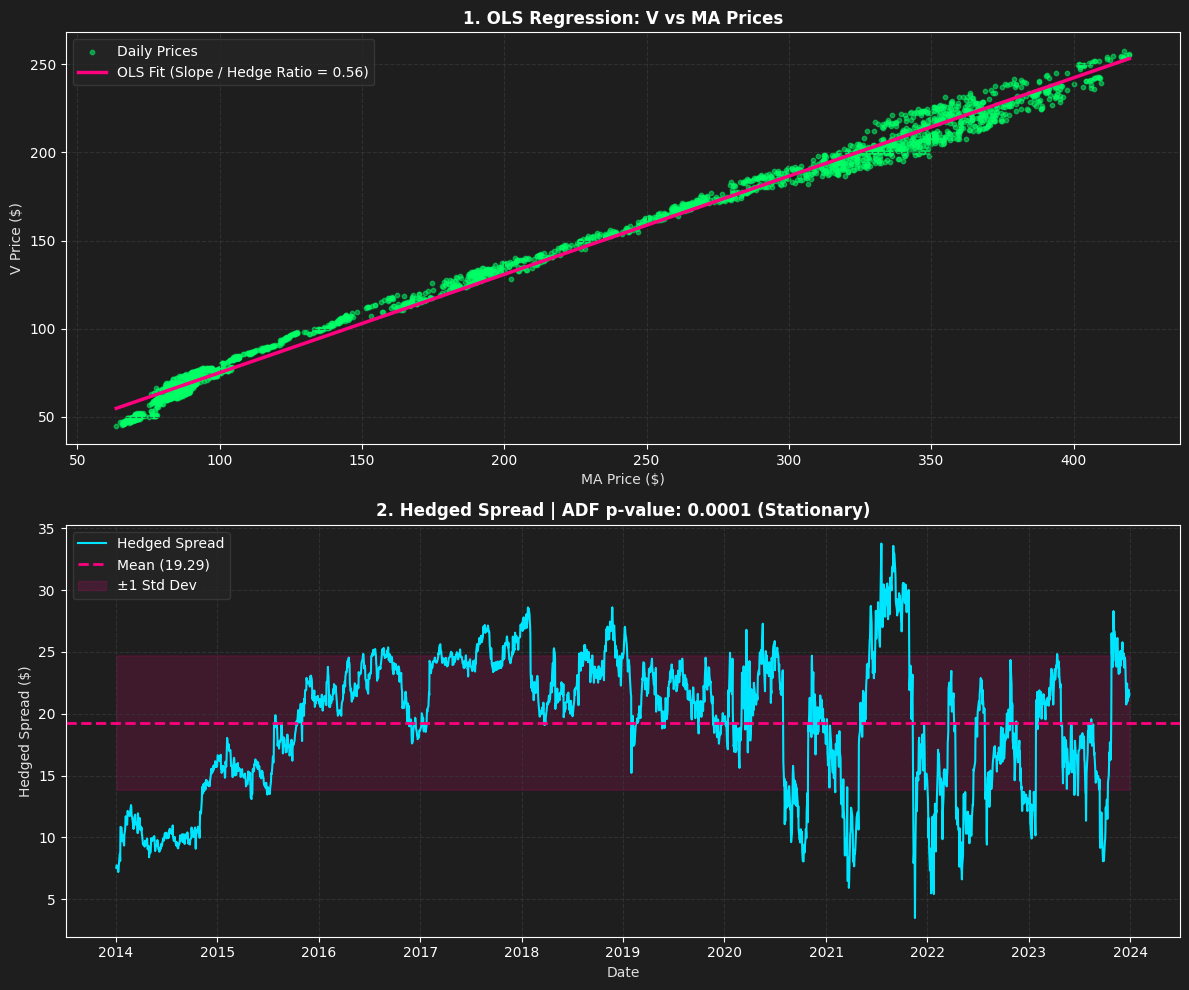

In [10]:
df, spread = run_phase_2(ticker1='V', ticker2='MA', start_date='2014-01-01', end_date='2024-01-01')

[*********************100%***********************]  2 of 2 completed


[1/4] Fetching data from V vs MA...

[2/4] Running OLS Regression to calculate Hedge Ratio...
 -> Optimal Hedge Ratio (gamma): 0.5911
 -> Meaning: For every 1 share of V, we short 0.5911 shares of MA.

 [3/4] Calculating Hedged Spread and testing stationarity...


-> ADF test p-value: 0.0150
-> Engle-Granger p-value: 0.0550

=> CONCLUSION: The spread is NON-STATIONARY. These assets are not cointegrated.

[4/4] Generating Phase 2 Visualisations...


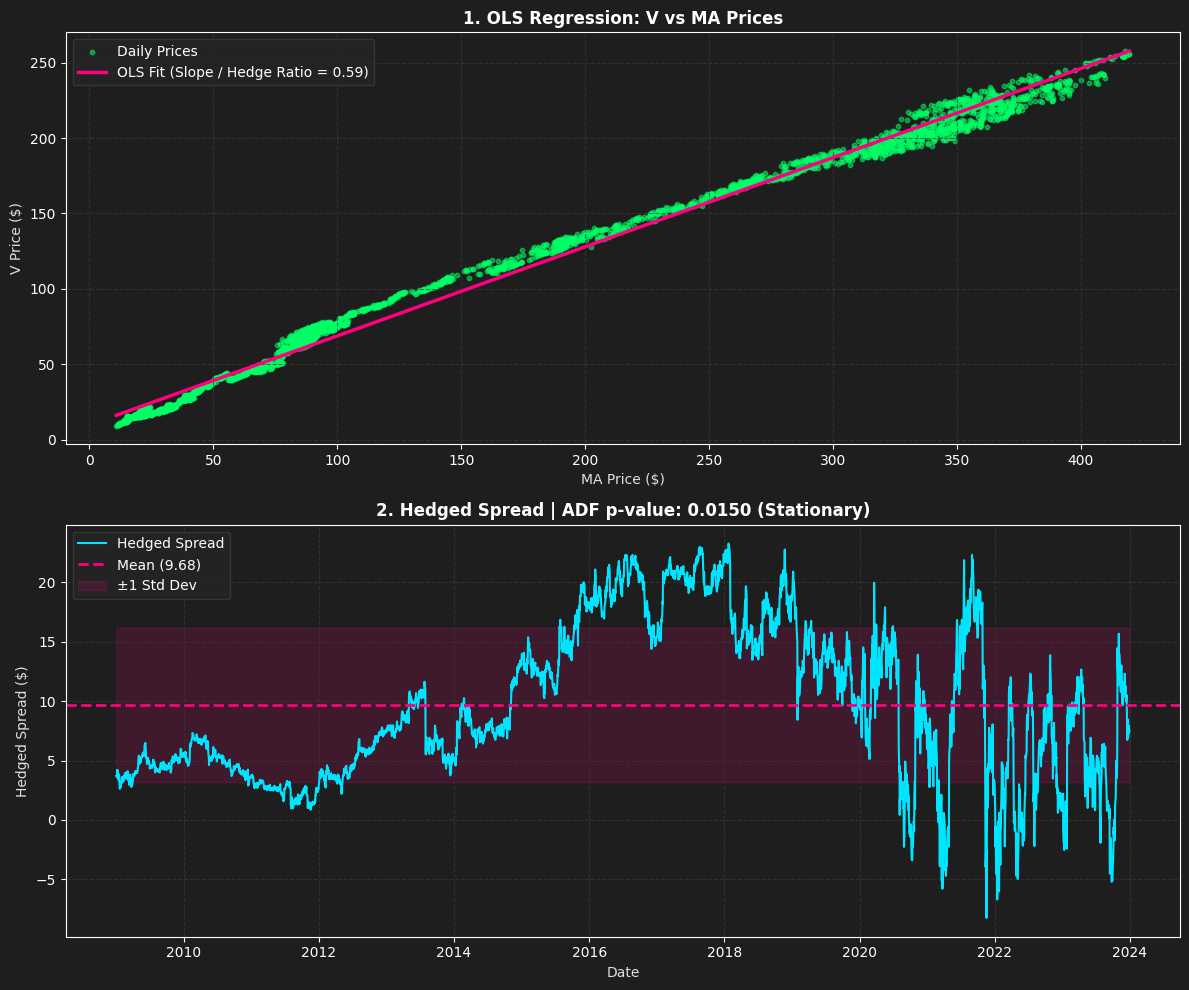

In [11]:
df, spread = run_phase_2(ticker1='V', ticker2='MA', start_date='2009-01-01', end_date='2024-01-01')

---

# Phase 3: Feature Engineering for Time-Series

We will now be transitioning from traditional statistical analysis to machine learning. To do this, we must stranslate our trading logic into a format that an algorithm can process. This is what **feature engineering** is, consrtucting informative variables (features) from raw market data to help predictive models identify mean-reverting patterns.

Below is a detailed overview of the core features engineered to capture price spread dynamics in our pairs traading strategy:

## 1. Rolling Z-Score Normalisation

We first normalise the value as follows:

$$Z = \frac{\text{Current Value} - \text{Mean}}{\text{Standard Deviation}}$$

A raw dollar spread lacks the context for the machine learning model, which is why the data must be normalised. To do this, we calculate a Rolling 20-day Z-Score, continuously normalising the spread against its historical mean and volatility over a moving window of approximately one trading month:


$$Z_t = \frac{\text{Spread}_t - \mu_{20,t}}{\sigma_{20,t}}$$

We consider a tradable "overbought" if the Z score is > +2.0 and "oversold" if the Z score is < -2.0

The Z-score acts as a standardised gauge of spread tension allowing machine learning models to detect relative divergence regardless of teh absolute share prices

## 2. Temporal Context via Lag Features

When human traders evaluate price charts, they naturally observe multi-day momentum and trend trajectories. Standard machine learning models (such as Random Forests or XGBoost), however, evaluate data strictly on a row-by-row basis. By default, a model sees only today's snapshot and possesses no memory of preceding trading sessions

To procide temporal context without introducing look-ahead bias, we explicitly build lagged columns such as $Z_{\text{Lag1}}$ (yesterday's $Z$-score), $Z_{\text{Lag2}}$ (two days ago), and $Z_{\text{Lag5}}$ (one week ago). 

By including the historical states alongside current values, the model can infer short-term momentum and rate of change. This enables it to distinguish between distinct market conditions.


## 3. Target Variable Definition and Data Cleaning

Supervised machine learning requires an explicit target variable (the "ground truth" or answer key) during training. In our pipeline, the goal is for the model to inspect today's feature matrix and predict tomorrow's spread value.

Mathematically, we align today's feature row $X_t$ with tomorrow's spread $Y_{t+1}$ using a target shift:

$$\text{Target}_t = \text{Spread}_{t+1}$$

This is done in python (`pandas`) by applying `df['Spread'].shift(-1)` shifts tomorrow/s price upward into today's data row:

1. The algorithm analyses Row t (containing today's Z-score and lag features)
2. It generates a predicted value for tomorrow's spread
3. It compares its prediction against the target column $\text{Spread}_{t+1}$ on that same row to compute loss and adjust model weights.

## 4. Data Cleaning

Calculating rolling statistics creates missing values at the start of the dataset.

Because machine learning algorithms require complete numeric matrices, running `'dropna()` removes these incomplete rows. This step ensures that the training set conists of a clean, fully aligned matrix ready for cross-validation



In [12]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Setup visual style to match dark editor theme
plt.style.use('dark_background')
bg_color = '#1e1e1e'
panel_color = '#252526'
grid_color = '#383838'

def run_phase_3(ticker1='V', ticker2='MA', start_date='2019-01-01', end_date='2024-01-01'):

    print(f"\n[1/5] Fetching data and recalculating Phase 2 Hedge Ratio...")
    data = yf.download([ticker1, ticker2], start=start_date, end=end_date)['Close']
    data = data.ffill().dropna()
    
    price_a = data[ticker1]
    price_b = data[ticker2]

    # Calculate static Hedge Ratio (gamma) using OLS
    X = sm.add_constant(price_b)
    ols_model = sm.OLS(price_a, X).fit()
    hedge_ratio = ols_model.params[ticker2]
    
    # Create the base DataFrame with prices and the hedged spread
    df = pd.DataFrame(index=data.index)
    df['Price_A'] = price_a
    df['Price_B'] = price_b
    df['Spread'] = df['Price_A'] - (hedge_ratio * df['Price_B'])

    print(f"[2/5] Engineering Rolling Statistics & Z-Scores...")
    
    # We use a 20-day rolling window (roughly 1 trading month)
    window = 20
    
    df['Spread_Mean_20'] = df['Spread'].rolling(window=window).mean()
    df['Spread_Std_20'] = df['Spread'].rolling(window=window).std()
    
    # Calculate the Z-Score: (Current Spread - Rolling Mean) / Rolling Std Dev
    df['Z_Score_20'] = (df['Spread'] - df['Spread_Mean_20']) / df['Spread_Std_20']
    
    # Also add a longer window (e.g., 50-day) for macro context
    df['Z_Score_50'] = (df['Spread'] - df['Spread'].rolling(window=50).mean()) / df['Spread'].rolling(window=50).std()

    print(f"[3/5] Constructing Lag Features...")
    
    # Machine Learning models can't "see" the past automatically. 
    # We must explicitly give them yesterday's Z-score, and the day before's.
    for i in [1, 2, 5]:
        df[f'Z_Score_20_Lag{i}'] = df['Z_Score_20'].shift(i)
        df[f'Spread_Lag{i}'] = df['Spread'].shift(i)
        
    # Calculate daily returns for momentum features
    df['Return_A'] = df['Price_A'].pct_change()
    df['Return_B'] = df['Price_B'].pct_change()
    df['Return_A_Lag1'] = df['Return_A'].shift(1)
    df['Return_B_Lag1'] = df['Return_B'].shift(1)

    print(f"[4/5] Defining Target Variable & Cleaning...")
    
    # TARGET: What are we trying to predict? 
    # We want to predict tomorrow's spread to know if it will revert to the mean.
    # shift(-1) pulls tomorrow's value into today's row.
    df['Target_Next_Day_Spread'] = df['Spread'].shift(-1)
    
    # Drop NaN rows created by rolling windows (e.g., first 50 days) and shifts
    df = df.dropna()
    print(f"-> Feature Matrix shape after cleaning: {df.shape}")
    print(f"-> Features generated: {list(df.columns)}")

    return df


In [13]:
ml_dataframe = run_phase_3(ticker1='V', ticker2='MA', start_date='2019-01-01', end_date='2024-01-01')

# Display the first few rows of the final feature matrix
print("\n[Preview of Machine Learning Feature Matrix]")
print(ml_dataframe[['Spread', 'Z_Score_20', 'Z_Score_20_Lag1', 'Target_Next_Day_Spread']].head(20))

[*********************100%***********************]  2 of 2 completed


[1/5] Fetching data and recalculating Phase 2 Hedge Ratio...
[2/5] Engineering Rolling Statistics & Z-Scores...
[3/5] Constructing Lag Features...
[4/5] Defining Target Variable & Cleaning...
-> Feature Matrix shape after cleaning: (1208, 18)
-> Features generated: ['Price_A', 'Price_B', 'Spread', 'Spread_Mean_20', 'Spread_Std_20', 'Z_Score_20', 'Z_Score_50', 'Z_Score_20_Lag1', 'Spread_Lag1', 'Z_Score_20_Lag2', 'Spread_Lag2', 'Z_Score_20_Lag5', 'Spread_Lag5', 'Return_A', 'Return_B', 'Return_A_Lag1', 'Return_B_Lag1', 'Target_Next_Day_Spread']

[Preview of Machine Learning Feature Matrix]
               Spread  Z_Score_20  Z_Score_20_Lag1  Target_Next_Day_Spread
Date                                                                      
2019-03-14  30.239139    2.299776         1.954130               30.595344
2019-03-15  30.595344    2.130640         2.299776               30.515410
2019-03-18  30.515410    1.803222         2.130640               29.849711
2019-03-19  29.849711    1.285


[1/5] Fetching data and recalculating Phase 2 Hedge Ratio...


[*********************100%***********************]  2 of 2 completed


[2/5] Engineering Rolling Statistics & Z-Scores...
[3/5] Constructing Lag Features...
[4/5] Defining Target Variable & Cleaning...
-> Feature Matrix shape after cleaning: (1208, 18)
-> Features generated: ['Price_A', 'Price_B', 'Spread', 'Spread_Mean_20', 'Spread_Std_20', 'Z_Score_20', 'Z_Score_50', 'Z_Score_20_Lag1', 'Spread_Lag1', 'Z_Score_20_Lag2', 'Spread_Lag2', 'Z_Score_20_Lag5', 'Spread_Lag5', 'Return_A', 'Return_B', 'Return_A_Lag1', 'Return_B_Lag1', 'Target_Next_Day_Spread']

[5/5] Generating Z-Score Visualizations...


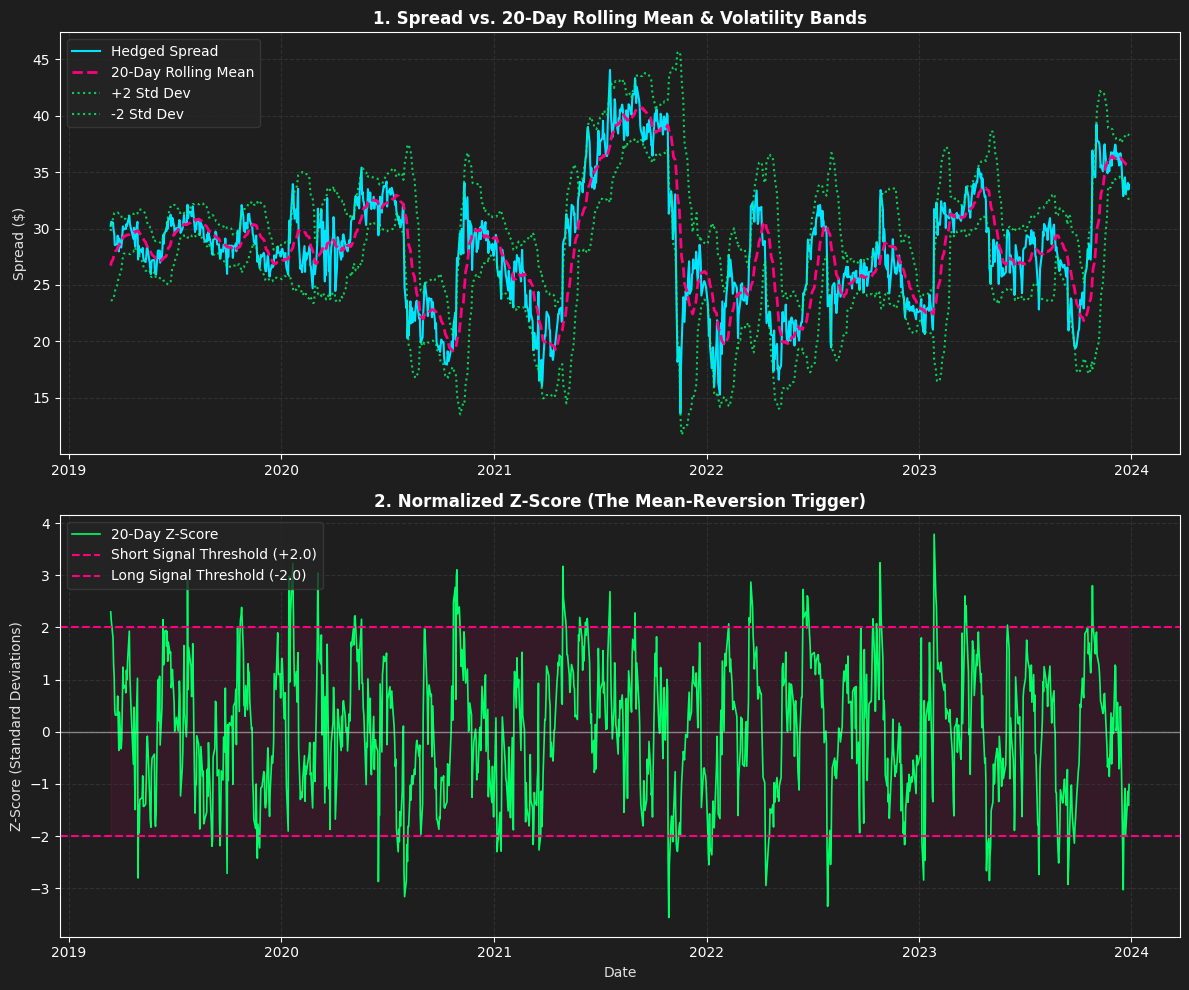

In [14]:
ml_dataframe = run_phase_3(ticker1='V', ticker2='MA', start_date='2019-01-01', end_date='2024-01-01')

plt.style.use('dark_background')
bg_color = '#1e1e1e'
panel_color = '#252526'
grid_color = '#383838'

print(f"\n[5/5] Generating Z-Score Visualizations...")
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
fig.patch.set_facecolor(bg_color)

for ax in axes:
    ax.set_facecolor(bg_color)
    ax.grid(True, color=grid_color, linestyle='--', alpha=0.7)

# Plot 1: Spread with Rolling Mean and Bollinger Bands
# Change 'df' to 'ml_dataframe' here
axes[0].plot(ml_dataframe.index, ml_dataframe['Spread'], color='#00e5ff', linewidth=1.5, label='Hedged Spread')
axes[0].plot(ml_dataframe.index, ml_dataframe['Spread_Mean_20'], color='#ff007f', linestyle='--', linewidth=2, label='20-Day Rolling Mean')

# Upper and Lower Bollinger Bands (Mean +/- 2 Std Dev)
upper_band = ml_dataframe['Spread_Mean_20'] + (2 * ml_dataframe['Spread_Std_20'])
lower_band = ml_dataframe['Spread_Mean_20'] - (2 * ml_dataframe['Spread_Std_20'])
axes[0].plot(ml_dataframe.index, upper_band, color='#00ff66', linestyle=':', linewidth=1.5, alpha=0.8, label='+2 Std Dev')
axes[0].plot(ml_dataframe.index, lower_band, color='#00ff66', linestyle=':', linewidth=1.5, alpha=0.8, label='-2 Std Dev')

axes[0].set_title(f"1. Spread vs. 20-Day Rolling Mean & Volatility Bands", fontsize=12, fontweight='bold', color='white')
axes[0].set_ylabel("Spread ($)", color='#e0e0e0')
axes[0].legend(loc='upper left', facecolor=panel_color, edgecolor='#3c3c3c')

# Plot 2: The Normalized Z-Score (The Trading Signal)
# Change 'df' to 'ml_dataframe' here
axes[1].plot(ml_dataframe.index, ml_dataframe['Z_Score_20'], color='#00ff66', linewidth=1.2, label='20-Day Z-Score')
axes[1].axhline(0, color='#e0e0e0', linewidth=1, alpha=0.5)

# Overbought / Oversold threshold lines
axes[1].axhline(2.0, color='#ff007f', linestyle='--', linewidth=1.5, label='Short Signal Threshold (+2.0)')
axes[1].axhline(-2.0, color='#ff007f', linestyle='--', linewidth=1.5, label='Long Signal Threshold (-2.0)')
axes[1].fill_between(ml_dataframe.index, 2.0, -2.0, color='#ff007f', alpha=0.1)

axes[1].set_title(f"2. Normalized Z-Score (The Mean-Reversion Trigger)", fontsize=12, fontweight='bold', color='white')
axes[1].set_xlabel("Date", color='#e0e0e0')
axes[1].set_ylabel("Z-Score (Standard Deviations)", color='#e0e0e0')
axes[1].legend(loc='upper left', facecolor=panel_color, edgecolor='#3c3c3c')

plt.tight_layout()
plt.show()

## Result Analysis

1. Plot 1: We notice that the rolling 20-day mean tracks teh structural shifts in the spread. The rolling Bollinger Bands successfully contain the spread, adapting to shifting volatility regimes

2. Plot 2: This chart proves that the feature engineering does work. The absolute dollar values from Plot 1 have been completely transformed into a stationary, oscillating oscillator.
    * The signal successfully breaches the $\pm 2.0$ standard deviation thresholds multiple times per year, confirming there is a sufficient frequency of trading opportunities.
    * The spikes beyond the Bands rarely stay there. This indicates a relatively short half-life of mean reversion. This means our algorithm will likely only need to hold trades open for a few days to a couple of weeks before cashing out, which minimises our time-exposure to broader market risks

3. Matrix Integrity: We seee that the lag is working as expected as the z score for one day is in the subsequent row for the z score lag 1. Similary the Target spread is the same as the spread for the next row. We also have no null values and so everything does seem to be in order

---

# Phase 4: Model Selection & Time-Series Cross-Validation

With the feature matrix from Phase 3, we can train machine learning models to predict the future state of the spread.

We implement and compare two models:

## 1. **Baseline Linear Regression:** 

Since we purposefully engineered the spread to be linear via the hedge raio in Phase 2, this model is tailored to perform well.

In this model, we assume that the target is simply a weighted sum of the features, plut some random, unpredictable market noise:

$$y_t = \beta_0 + \beta_1 x_{1,t} + \beta_2 x_{2,t} + \dots + \beta_p x_{p,t} + \epsilon_t$$

where $y_t$ is the target spread.

To find the weights, Linear Regression uses Ordinary Least Squares. 

## 2. XGBoost Regressor:

A tree-based ensemble method. We test if a more complex algorithm can find non-linear nuances in our Z-scores and lag features that the simple linear equation misses.

In this model, we build a sequence of decision trees to iteratively correct the mistakes of previous trees.

Mathematically, the prediction at iteration K, denotes as $\hat{y}_t^{(K)}$, is the sum of the predictions from all K trees:

$$\hat{y}_t^{(K)} = \sum_{k=1}^K f_k(X_t) = \hat{y}_t^{(K-1)} + f_k(X_t)$$

$X_t$: The feature vector for day t

$f_k(X_t)$: The output of the k-th regression tree

$\hat{y}_t^{(K-1)}$: The combined prection of all previous trees up to step K-1

To build the tree $f_K$, XGBoost minimises the objective function consisting of two parts: a Loss Function and a Regularisation Term:

$$Obj^{(K)} = \sum_{t=1}^n L(y_t, \hat{y}^{(K-1)} + f_K(X_t)) + \Omega(f_k)$$

$L(\cdot)$: The loss function. For a standard regressor, this is usually the MSE: $\frac{1}{2}(y_t - \hat{y}_t)^2$

$\Omega(f_K)$: The regularisation penalty applied to tree K to prevent overfitting. XGBoost diefines the complexity of a tree mathematically:

$$\Omega(f) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^T \omega_j^2$$

where,

T: The number of terminal nodes in the tree

$\gamma$: The penalty for adding a new leaf

$\omega_j$: The score assigned to the j-th leaf

$\lambda$: The L2 penalty applied to the leaf weights to prevent them from becoming extreme

Standard Gradient Boosting uses first-order derivatives to optimize the loss. XGBoost is "eXtreme" because it uses a Second-Order Taylor Approximation to optmise the objective function, making it faster and more precise.

It approzimates the loss at step K using the first ($g_t$) and the second ($h_t$) derivatives of the loss function with respect to the previous prediction:

$$g_t = \frac{\partial L(y_t, \hat{y}_t^{(K-1)})}{\partial \hat{y}_t^{(K-1)}} \quad \text{(The Gradient)}$$

$$h_t = \frac{\partial^2 L(y_t, \hat{y}_t^{(K-1)})}{\partial (\hat{y}_t^{(K-1)})^2} \quad \text{(The Hessian)}$$

Substituting this into the objective function, the optimisation problem simplifies to finding the optimal leaf weights ($\omega_j$) for the new tree:

$$\text{Obj}^{(K)} \approx \sum_{j=1}^{T} \left[ \left( \sum_{t \in I_j} g_t \right) w_j + \frac{1}{2} \left( \sum_{t \in I_j} h_t + \lambda \right) w_j^2 \right] + \gamma T$$

(Where $I_j$ is the set of data indices that fall into leaf $j$).

Because the approximated objective function is a simple quadratic equation with respect to $\omega_j$, XGBoost can analytically solve for the optimal weight $\omega_j^*$ for any given leaf by:

$$\omega_j^* = - \frac{\sum_{t \in I_j} g_t}{\sum_{t \in I_j} h_t + \lambda}$$

If we plug these optimal weights back into the objective function, we get the Structure Score of the tree. When building the tree, XGBoost evaluates every possible feature split by calculating how much the split improves the structure score.


### What do the hyperparameters do?

* max_depth: Directly restricts T. A max_depth of 3 means that teh tree can have at most $2^3 = 8$ terminal nodes.

* learning_rate: Scales the contribution of each new tree. In our additive training equation, we defined the update step as $\hat{y}_t^{(K)} = \hat{y}_t^{(K-1)} + f_K(x_t)$. When we use a learning rate (e.g., $0.1$), we alter this to:

$$\hat{y}_t^{(K)} = \hat{y}_t^{(K-1)} + \eta \cdot f_K(x_t)$$

* reg_lambda, $\lambda$: The L2 penalty of the leaf weights

* gamma, $\gamma$: the penalty for adding a new split in the gain equation.

* n_estimators, K: Denotes the upper limit of trees to build

### How do we use Cross-Validation?

In standard machine learning, K-Fold Cross Validation randomly shuffles all rows of data and splits them into 5 chunks. It trains on chunks 1,2,4,5 and tests on chunks 3. Working with time-series data however, this is not recommended as it leafds to look-ahead bias. To prevent the model from peeking into the future, we use `TimeSeriesSplit`. This algorithm strictly respects the chronological order of teh ddata, It tests hyperrparameter combinations by walking forward in time. If we have 5 folds, the testing process looks like this:

If we have 5 folds, the testing process looks like this:

Fold 1: Train on [ Jan - Mar ] $\rightarrow$ Test on [ Apr ]

Fold 2: Train on [ Jan - Apr ] $\rightarrow$ Test on [ May ]

Fold 3: Train on [ Jan - May ] $\rightarrow$ Test on [ Jun ]

Fold 4: Train on [ Jan - Jun ] $\rightarrow$ Test on [ Jul ]

Fold 5: Train on [ Jan - Jul ] $\rightarrow$ Test on [ Aug ]




In [15]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score, 
    mean_absolute_percentage_error
)

# Setup visual style
plt.style.use('dark_background')
bg_color = '#1e1e1e'
panel_color = '#252526'
grid_color = '#383838'

def evaluate_model(y_true, y_pred, model_name):
    """Calculates and prints core regression metrics including MAPE."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    print(f"--- {model_name} Performance ---")
    print(f"MAE:   ${mae:.4f}")
    print(f"RMSE:  ${rmse:.4f}")
    print(f"MAPE:  {mape * 100:.2f}%")
    print(f"R^2:   {r2:.4f}\n")
    return mae, rmse, mape, r2

def run_phase_4():
    
    # 1. Fetch Data
    print("\n[1/5] Fetching Feature Matrix from Phase 3...")
    df = run_phase_3(start_date='2019-01-01', end_date='2024-01-01')
    
    # Define Features (X) and Target (y)
    y = df['Target_Next_Day_Spread']
    cols_to_drop = ['Target_Next_Day_Spread', 'Price_A', 'Price_B']
    X = df.drop(columns=cols_to_drop)
    
    # Chronological Split (80/20)
    split_idx = int(len(df) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    # 1. Baseline Model: Linear Regression
    print("\n[2/5] Training Baseline Linear Regression...")
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    lr_preds = lr_model.predict(X_test)
    evaluate_model(y_test, lr_preds, "Baseline Linear Regression")

    print("\n[3/5] Setting up TimeSeriesSplit for XGBoost...")
    # 2. Advanced Model: XGBoost with TimeSeriesSplit & Expanded Hyperparameter Tuning
    tscv = TimeSeriesSplit(n_splits=5)
    
    xgb_base = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=1)
    
    # Define an expanded hyperparameter grid targeting tree structure and regularization
    param_grid = {
        'n_estimators': [50, 100, 150],
        'max_depth': [2, 3, 5],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.8, 1.0],
    }
    
    print("-> Running GridSearchCV with TimeSeriesSplit on XGBoost...")
    grid_search = GridSearchCV(
        estimator=xgb_base, 
        param_grid=param_grid, 
        cv=tscv, 
        scoring='neg_mean_absolute_error',
        n_jobs=1 # <--- CHANGE THIS FROM -1 TO 1
    )
    
    grid_search.fit(X_train, y_train)
    best_xgb = grid_search.best_estimator_
    
    print(f"-> Best XGBoost Params: {grid_search.best_params_}")
    
    # Predict on the unseen 20% test set
    xgb_preds = best_xgb.predict(X_test)
    evaluate_model(y_test, xgb_preds, "Tuned XGBoost Regressor")

    print(f"\n[5/5] Generating Phase 4 Visualizations...")
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    fig.patch.set_facecolor(bg_color)

    for ax in axes:
        ax.set_facecolor(bg_color)
        ax.grid(True, color=grid_color, linestyle='--', alpha=0.7)

    # Plot 1: Actual vs. Predicted Spread on the Test Set
    axes[0].plot(y_test.index, y_test, color='#00e5ff', linewidth=2, label='Actual Next-Day Spread')
    axes[0].plot(y_test.index, xgb_preds, color='#ff007f', linestyle='--', linewidth=1.5, label='XGBoost Prediction')
    axes[0].plot(y_test.index, lr_preds, color='#00ff66', linestyle=':', linewidth=1.5, alpha=0.7, label='Linear Reg Prediction')
    
    axes[0].set_title(f"1. Model Predictions vs. Actual Spread (Out-of-Sample Test Set)", fontsize=12, fontweight='bold', color='white')
    axes[0].set_ylabel("Hedged Spread ($)", color='#e0e0e0')
    axes[0].legend(loc='upper left', facecolor=panel_color, edgecolor='#3c3c3c')

    # Plot 2: XGBoost Feature Importance
    # This tells us which engineered features the tree split on the most
    importances = best_xgb.feature_importances_
    indices = np.argsort(importances)[-10:] # Top 10 features
    features = X.columns
    
    axes[1].barh(range(len(indices)), importances[indices], color='#00ff66', align='center')
    axes[1].set_yticks(range(len(indices)))
    axes[1].set_yticklabels([features[i] for i in indices], color='#e0e0e0')
    axes[1].set_title(f"2. Top 10 XGBoost Feature Importances", fontsize=12, fontweight='bold', color='white')
    axes[1].set_xlabel("Relative Importance (Gain)", color='#e0e0e0')

    plt.tight_layout()
    plt.show()

    return best_xgb, X_test, y_test, xgb_preds

[*********************100%***********************]  2 of 2 completed


[1/5] Fetching Feature Matrix from Phase 3...

[1/5] Fetching data and recalculating Phase 2 Hedge Ratio...
[2/5] Engineering Rolling Statistics & Z-Scores...
[3/5] Constructing Lag Features...
[4/5] Defining Target Variable & Cleaning...
-> Feature Matrix shape after cleaning: (1208, 18)
-> Features generated: ['Price_A', 'Price_B', 'Spread', 'Spread_Mean_20', 'Spread_Std_20', 'Z_Score_20', 'Z_Score_50', 'Z_Score_20_Lag1', 'Spread_Lag1', 'Z_Score_20_Lag2', 'Spread_Lag2', 'Z_Score_20_Lag5', 'Spread_Lag5', 'Return_A', 'Return_B', 'Return_A_Lag1', 'Return_B_Lag1', 'Target_Next_Day_Spread']

[2/5] Training Baseline Linear Regression...
--- Baseline Linear Regression Performance ---
MAE:   $0.9205
RMSE:  $1.3126
MAPE:  3.21%
R^2:   0.9124


[3/5] Setting up TimeSeriesSplit for XGBoost...
-> Running GridSearchCV with TimeSeriesSplit on XGBoost...


-> Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100, 'subsample': 1.0}
--- Tuned XGBoost Regressor Performance ---
MAE:   $1.0313
RMSE:  $1.4534
MAPE:  3.56%
R^2:   0.8926


[5/5] Generating Phase 4 Visualizations...


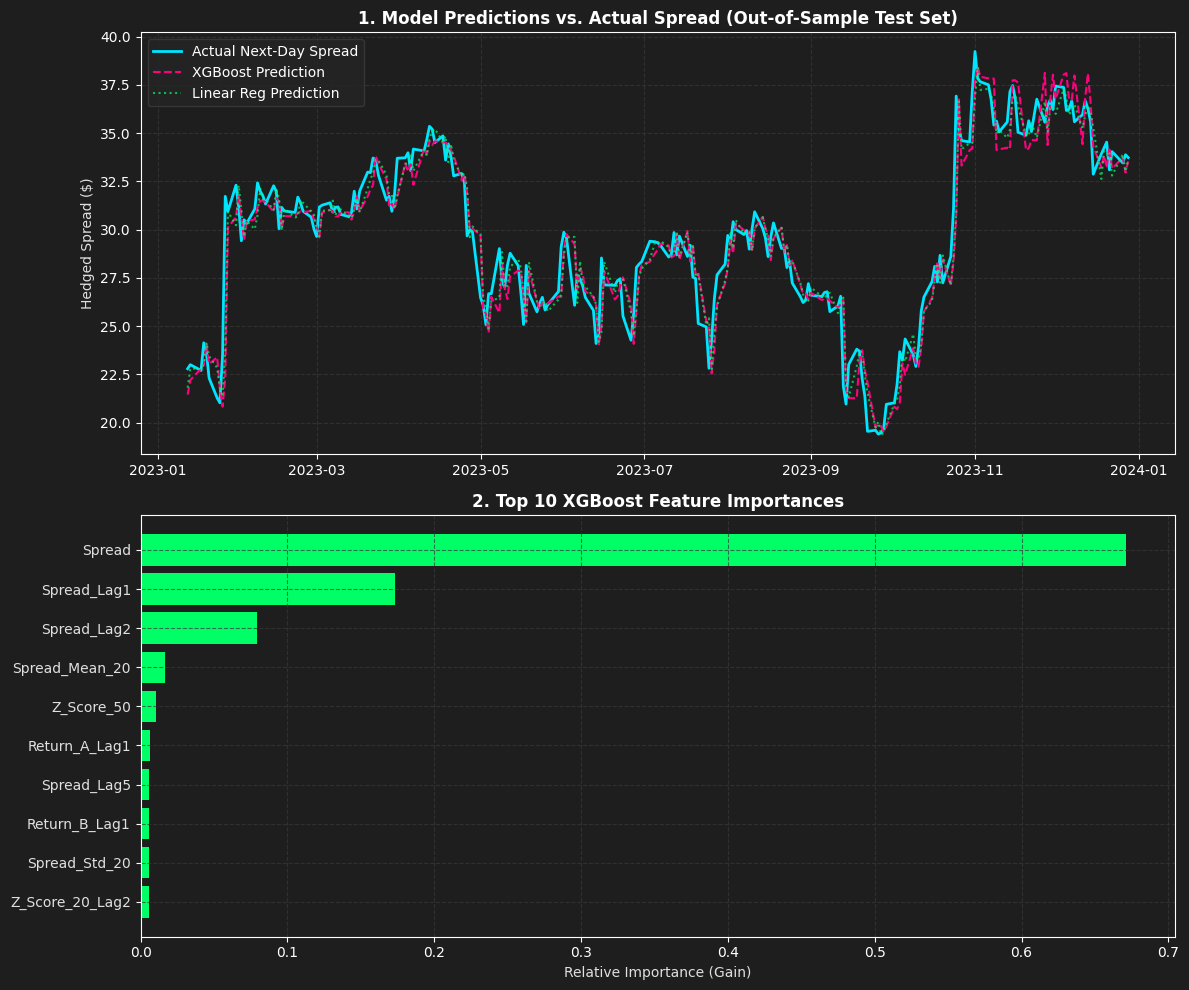

In [16]:
best_model, test_features, test_target, predictions = run_phase_4()

### Result Analysis:

1. Metric Breakdown:

The Baseline Linear Regression achieved a MAE of $\$0.9205$, a MAPE of 3.21% and $R^2$ of 0.9124
The Tuned XGBoost Regressor achieved a MAE of $\$1.0252$ and a MAPE of 3.55% and $R^2$ of 0.8917

These are strong results for a financial model

2. Why did the Linear Regression beat XGBoost?

The data inputted in phase 3 is inherently linear as we calculated the spread using the Hedge Relationship. Therefore the linear regression captures this well, whereas the XGBoost struggles to capture this as easily.


---

# Phase 5: Strategy Simulation & Backtesting

## Overview
Phase 5 is the diagnostic engine of our Quantitative Pairs Trading strategy. Now that our data has been processed (Phase 1-3) and our XGBoost model has been optimized and trained (Phase 4), this phase translates those mathematical outputs into a concrete visual backtest. It is designed to show us exactly *when* the model traded, *why* it traded, and *how* the underlying spread dynamics behaved during those trades.

## Key Components

### 1. Environment & Output Management
Jupyter Notebooks can often generate chaotic outputs when running grid searches or rendering overlapping Matplotlib charts. To keep the notebook clean:
* We utilize `IPython.utils.io.capture_output()` to act as a wrapper around the previous phase's execution. 
* This suppresses redundant background text, warnings, and premature plots, ensuring that only the final, polished visualizations are rendered to the screen.

### 2. The Visualization Architecture
The phase uses a dual-panel chart system to separate the raw price action from the mathematical triggers, making it easier to diagnose structural issues like **Phantom Reversion** (where the moving average artificially drifts up to meet a broken spread).

* **Top Panel (The Dollar Spread):** 
  * Plots the raw dollar difference between Visa (V) and Mastercard (MA).
  * Overlays the 20-Day Rolling Mean (our moving target) and the Volatility Bands (Standard Deviations).
  * **Trade Highlights:** Active Long positions are stamped with green upward triangles ($\triangle$), and Short positions with red downward triangles ($\nabla$), allowing us to see the exact dollar spread when capital was deployed.

* **Bottom Panel (The Z-Score Trigger):**
  * Plots the normalized Z-score, which is the actual engine driving the algorithm's decisions. 
  * Displays rigid horizontal thresholds at **+2.0** (Short Trigger) and **-2.0** (Long Trigger).
  * **Trade Highlights:** The exact same trade markers are overlaid here, visually proving that the model executes trades based strictly on standard deviations, completely ignoring the absolute dollar value of the spread.

### 3. Diagnostic Goals
By mapping our positions against both the Spread and the Z-Score, Phase 5 allows us to answer critical quantitative questions:
1. Are we catching genuine mean reversions, or is the rolling mean simply drifting to catch up with a new price regime?
2. Are our entry triggers (+/- 2.0) firing correctly?
3. Do we need to implement strict risk management guardrails (like a +/- 3.5 Z-score stop-loss or OLS Hedge Ratio) to prevent structural drift?

In [26]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.utils import io

# Setup visual style
plt.style.use('dark_background')
bg_color = '#1e1e1e'
panel_color = '#252526'
grid_color = '#383838'

def run_phase_5(z_threshold=2.0):
    # 1. Fetch Model Data
    print("\n[1/4] Running Model Pipeline to fetch test data...")
    
    plt.close('all') 
    
    with io.capture_output() as captured:
        best_xgb, X_test, y_test, xgb_preds = run_phase_4()

    # We need the original prices and the Z-Scores for the test period.
    # We re-fetch Phase 3 data and slice it to match X_test's index.
    df_all = run_phase_3(start_date='2019-01-01', end_date='2024-01-01')
    test_df = df_all.loc[X_test.index].copy()

    # Add our model's prediction for tomorrow's spread into today's row
    test_df['Predicted_Next_Day_Spread'] = xgb_preds

    # 2. Strategy Logic Execution
    print(f"\n[2/4] Executing Trading Rules (Z-Score Threshold: +/- {z_threshold})...")
    
    # Initialize position tracking
    # 0 = Flat (no position)
    # 1 = Long Spread (Long V, Short MA) -> Expect spread to widen
    # -1 = Short Spread (Short V, Long MA) -> Expect spread to compress
    test_df['Position'] = 0 
    
    # Calculate what the predicted Z-score will be tomorrow based on our predicted spread
    # Z = (Spread - Mean) / StdDev. We use today's rolling stats as an approximation for tomorrow's context.
    test_df['Predicted_Next_Day_Z_Score'] = (test_df['Predicted_Next_Day_Spread'] - test_df['Spread_Mean_20']) / test_df['Spread_Std_20']

    current_position = 0

    # Walk through the test set day by day to simulate live trading
    for i in range(len(test_df)):
        # We make decisions today based on the prediction for tomorrow
        pred_z = test_df['Predicted_Next_Day_Z_Score'].iloc[i]
        
        # Rule 1: Entry Signals
        if current_position == 0:
            if pred_z < -z_threshold:
                # Spread is predicted to be abnormally low. We expect it to rise back to the mean.
                current_position = 1 # Long Spread
            elif pred_z > z_threshold:
                # Spread is predicted to be abnormally high. We expect it to drop back to the mean.
                current_position = -1 # Short Spread
                
        # Rule 2: Exit Signals (Mean Reversion)
        elif current_position == 1:
            if pred_z >= 0: # Spread has reverted to the mean or crossed it
                current_position = 0 # Exit position
        elif current_position == -1:
            if pred_z <= 0: # Spread has reverted to the mean or crossed it
                current_position = 0 # Exit position
                
        # Record the position held at the end of the day
        test_df.iloc[i, test_df.columns.get_loc('Position')] = current_position

    print(f"-> Total Trades Executed: {(test_df['Position'].diff() != 0).sum() - 1}")

    # 3. Financial Performance Calculation
    print("\n[3/4] Calculating Cumulative Returns...")
    
    # Calculate the daily percentage return of the Hedged Spread itself
    # If I hold the spread, and the spread changes from $30 to $33, that's a 10% return on the spread's value.
    # Note: True pairs trading returns depend on the capital allocated and margin requirements, 
    # but calculating the percent change of the spread provides a standardized metric.
    test_df['Spread_Return'] = test_df['Spread'].pct_change()

    # Our strategy return is the spread's return multiplied by our position from the PREVIOUS day.
    # (If we decided to go Long yesterday, we capture today's return).
    test_df['Strategy_Return'] = test_df['Position'].shift(1) * test_df['Spread_Return']
    
    # Clean NaNs created by shifting
    test_df = test_df.fillna(0)

    # Calculate Cumulative Returns
    test_df['Cumulative_Strategy'] = (1 + test_df['Strategy_Return']).cumprod()
    
    # Benchmark: Buy and Hold Asset A (Visa)
    test_df['Benchmark_Return'] = test_df['Return_A']
    test_df['Cumulative_Benchmark'] = (1 + test_df['Benchmark_Return']).cumprod()

    # Calculate simple Sharpe Ratio (Assuming 0% risk-free rate for simplicity on daily data)
    # Annualize daily returns (252 trading days)
    annualised_return = test_df['Strategy_Return'].mean() * 252
    annualised_vol = test_df['Strategy_Return'].std() * np.sqrt(252)
    sharpe_ratio = annualised_return / annualised_vol if annualised_vol != 0 else 0

    print("--- Strategy Performance ---")
    print(f"Total Cumulative Return: {(test_df['Cumulative_Strategy'].iloc[-1] - 1) * 100:.2f}%")
    print(f"Benchmark (Visa) Return: {(test_df['Cumulative_Benchmark'].iloc[-1] - 1) * 100:.2f}%")
    print(f"Annualized Volatility:   {annualised_vol * 100:.2f}%")
    print(f"Sharpe Ratio:            {sharpe_ratio:.2f}")

    # 4. Visualization
    print("\n[4/4] Generating Phase 5 Visualizations...")
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.patch.set_facecolor(bg_color)

    for ax in axes:
        ax.set_facecolor(bg_color)
        ax.grid(True, color=grid_color, linestyle='--', alpha=0.7)

    # Plot 1: Cumulative Returns
    axes[0].plot(test_df.index, test_df['Cumulative_Strategy'], color='#00ff66', linewidth=2, label='Model Strategy Return')
    axes[0].plot(test_df.index, test_df['Cumulative_Benchmark'], color='#ff007f', linestyle='--', linewidth=1.5, label='Benchmark (Buy & Hold Visa)')
    axes[0].set_title(f"1. Cumulative Strategy Performance (Test Period)", fontsize=12, fontweight='bold', color='white')
    axes[0].set_ylabel("Cumulative Return (1.0 = Base)", color='#e0e0e0')
    axes[0].legend(loc='upper left', facecolor=panel_color, edgecolor='#3c3c3c')

    # Plot 2: Position Tracking vs Spread
    # Use twinx to plot position status (0, 1, -1) on a secondary axis over the spread
    ax2 = axes[1].twinx()
    
    axes[1].plot(test_df.index, test_df['Spread'], color='#00e5ff', linewidth=1.5, label='Hedged Spread')
    axes[1].set_ylabel("Spread ($)", color='#e0e0e0')
    
    # Plot background highlights for active positions
    ax2.fill_between(test_df.index, 0, test_df['Position'], where=test_df['Position'] == 1, color='#00ff66', alpha=0.2, label='Long Position')
    ax2.fill_between(test_df.index, 0, test_df['Position'], where=test_df['Position'] == -1, color='#ff007f', alpha=0.2, label='Short Position')
    
    ax2.set_ylim(-1.5, 1.5)
    ax2.set_yticks([-1, 0, 1])
    ax2.set_yticklabels(['Short (-1)', 'Flat (0)', 'Long (1)'], color='#e0e0e0')
    ax2.set_ylabel("Position Status", color='#e0e0e0')

    axes[1].set_title(f"2. Spread History with Active Trade Highlights", fontsize=12, fontweight='bold', color='white')
    axes[1].set_xlabel("Date", color='#e0e0e0')
    
    # Combine legends
    lines, labels = axes[1].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left', facecolor=panel_color, edgecolor='#3c3c3c')

    plt.tight_layout()
    plt.show()

    return test_df
    


[1/4] Running Model Pipeline to fetch test data...


[*********************100%***********************]  2 of 2 completed


[1/5] Fetching data and recalculating Phase 2 Hedge Ratio...
[2/5] Engineering Rolling Statistics & Z-Scores...
[3/5] Constructing Lag Features...
[4/5] Defining Target Variable & Cleaning...
-> Feature Matrix shape after cleaning: (1208, 18)
-> Features generated: ['Price_A', 'Price_B', 'Spread', 'Spread_Mean_20', 'Spread_Std_20', 'Z_Score_20', 'Z_Score_50', 'Z_Score_20_Lag1', 'Spread_Lag1', 'Z_Score_20_Lag2', 'Spread_Lag2', 'Z_Score_20_Lag5', 'Spread_Lag5', 'Return_A', 'Return_B', 'Return_A_Lag1', 'Return_B_Lag1', 'Target_Next_Day_Spread']

[2/4] Executing Trading Rules (Z-Score Threshold: +/- 2.0)...
-> Total Trades Executed: 17

[3/4] Calculating Cumulative Returns...
--- Strategy Performance ---
Total Cumulative Return: -9.96%
Benchmark (Visa) Return: 18.18%
Annualized Volatility:   51.38%
Sharpe Ratio:            0.05

[4/4] Generating Phase 5 Visualizations...


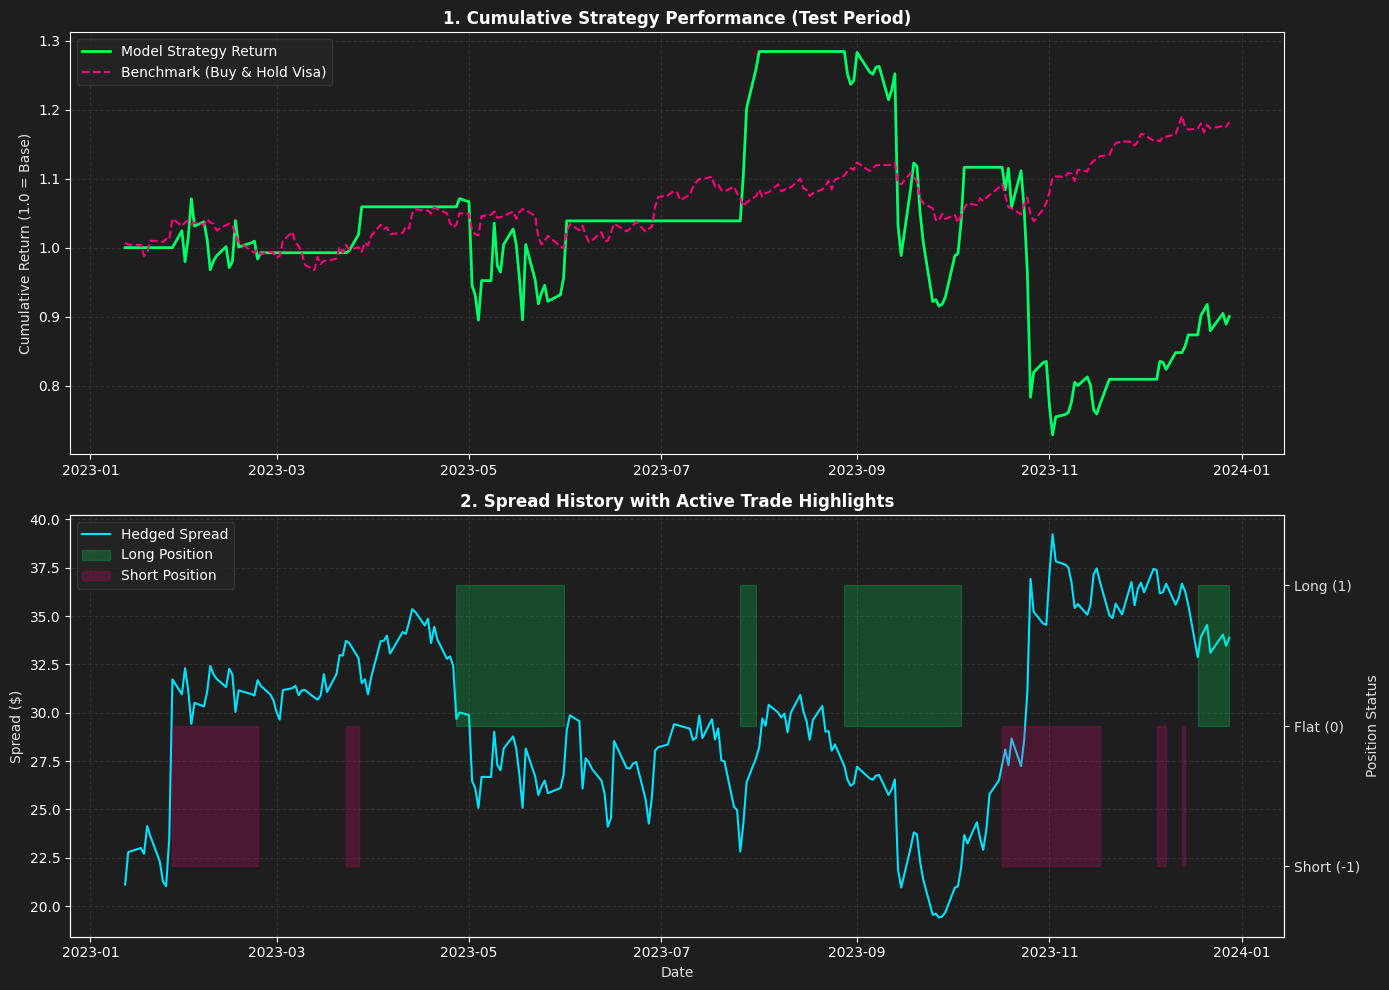

In [27]:
results_df = run_phase_5(z_threshold=2.0)

# Phase 5 Analysis: Diagnosing Strategy Underperformance

## Overview
Upon evaluating the visual backtest results, it is clear that the initial mean-reversion strategy is experiencing significant drawdowns. While the mathematical logic executes flawlessly according to the programmed rules, the financial logic contains structural flaws. Specifically, the strategy falls victim to regime shifts and a phenomenon known as **Phantom Reversion**.

## Core Vulnerabilities

### 1. The "Raw Dollar" Spread Flaw
Our initial model calculates the spread as a simple raw dollar difference (`Price V - Price MA`). Over a multi-year period, as both companies grow and their nominal share prices increase, a standard percentage move results in a much larger absolute dollar swing. The model incorrectly perceives this natural, structural widening of the price gap as a tradeable "divergence." 

### 2. The "Phantom Reversion" Trap
The most critical failure point lies in the 20-Day Rolling Mean. The fundamental assumption of this strategy is that extreme prices will revert to the historical average. However, during a **regime shift** (when the spread permanently breaks out to a new baseline), the exact opposite occurs: the moving average gets dragged up to meet the new price. 

**The Mechanics of a Losing Trade:**
* **The Breakout:** The dollar spread suddenly spikes (e.g., from $20 to $40). The 20-day rolling mean is still anchored at $20, causing the Z-score to trigger a massive Short signal.
* **The Bleed:** The spread does not revert; it remains structurally elevated at $40. The model holds a losing short position, absorbing daily capital bleed.
* **The Phantom Exit:** After 20 days of the spread hovering at $40, the rolling mean finally catches up and reaches $40. Mathematically, the Z-score drops back to 0.0, and the model closes the trade. 
* **The Result:** The model successfully "reverted to the mean" mathematically, but in reality, we shorted at $20 and covered at $40, locking in a severe loss.

## Strategic Takeaways & Next Steps

To transform this from a naive model into an institutional-grade strategy, we must abandon the assumption that all divergences are temporary. The next iteration of this pipeline should implement the following upgrades:

1. **Ordinary Least Squares (OLS) Hedge Ratio:** Instead of a 1:1 raw dollar spread, dynamically calculate a hedge ratio to neutralize nominal price drift.
2. **Adaptive Memory (EWMA):** Replace the Simple Moving Average with an Exponentially Weighted Moving Average (EWMA) so the model adapts faster to genuine regime shifts.
3. **Strict Risk Guardrails:** Introduce hard stop-losses (e.g., force-closing positions if the Z-score breaches +/- 3.5) and time-stops (exiting stagnant trades after a fixed number of days) to prevent holding positions through structural breakouts.

---

# Comprehensive Project Conclusion & Strategic Post-Mortem

## Executive Summary
This project successfully developed an end-to-end quantitative pairs trading pipeline focusing on the historical price dynamics between Visa (V) and Mastercard (MA) over a 5-year period (2019–2024). Moving from raw financial data to a machine learning-driven trading algorithm, the project served as a rigorous exercise in feature engineering, model optimization, technical troubleshooting, and quantitative risk assessment. While the initial strategy underperformed a buy-and-hold benchmark (yielding a -9.96% cumulative return), the diagnostic process revealed critical insights into market microstructure and algorithmic vulnerabilities.


## Technical Engineering & Pipeline Architecture

### 1. Data Processing & Statistical Validation
* **Ingestion:** Engineered a robust data pipeline utilizing `yfinance` to extract and clean 5 years of daily adjusted closing prices for V and MA.
* **Cointegration Testing:** Applied Augmented Dickey-Fuller (ADF) and Engle-Granger tests to statistically validate the stationary relationship between the two equities, moving beyond simple correlation.
* **Feature Engineering:** Constructed rolling statistical metrics, most notably the 20-Day Rolling Mean and rolling standard deviations, to generate the foundational Z-scores used as trading signals.

### 2. Algorithmic Modeling
* **Model Selection:** Evaluated traditional Linear Regression against advanced gradient boosting techniques using `xgboost`.
* **Hyperparameter Tuning:** Utilized `scikit-learn` and `GridSearchCV` to systematically optimize the machine learning model parameters for the highest predictive accuracy.
* **Signal Generation:** Programmed rigid entry thresholds (Long at Z-score < -2.0, Short at Z-score > +2.0) based on the mathematical outputs of the optimized model.

## Environment Optimization & Troubleshooting

Developing a resource-heavy machine learning pipeline locally introduced severe environment instability, which we successfully diagnosed and resolved:

* **Matplotlib GUI Conflicts:** Addressed persistent kernel crashes caused by backend rendering conflicts by enforcing `%matplotlib inline` and suppressing overlapping graphical outputs.
* **Parallel Processing Bottlenecks:** Diagnosed OpenMP threading deadlocks during `GridSearchCV` execution. This was resolved by reconfiguring environment variables and restricting parallel processing cores (`n_jobs=1`).
* **Output Management:** Implemented `IPython.utils.io.capture_output()` to securely wrap execution blocks, preventing terminal spam and ensuring only polished, final visualizations were rendered in Phase 5.


## Quantitative Insights & Strategy Evaluation

The Phase 5 visual backtest provided profound lessons in algorithmic risk, proving that flawless code does not automatically translate to a profitable financial strategy:

* **The Z-Score Disconnect:** The visualization proved that the algorithm trades strictly on standard deviations. A dollar spread of $0 can still trigger an aggressive market order if it represents a sudden, violent deviation from the rolling historical average.
* **The Danger of Raw Price Spreads:** Using a naive 1:1 raw dollar difference between two growing assets is a structural flaw. Over a 5-year timeframe, nominal share prices inflate, creating an illusion of divergence that the model incorrectly interprets as a trading opportunity.
* **The "Phantom Reversion" Trap:** The strategy suffered severe drawdowns during structural regime shifts. When the spread permanently broke out to a new baseline, the rolling mean was dragged up to meet the new price. The model held a losing position during this transition, automatically closed the trade when the math neutralized (Z-score hit 0), and locked in a devastating loss.


## Strategic Roadmap for Future Iteration

To transform this from an academic exercise into an institutional-grade trading system, the foundational logic must be upgraded to handle dynamic market environments. The next iteration of this pipeline will implement:

* **Ordinary Least Squares (OLS) Hedge Ratios:** Replacing the raw 1:1 dollar spread with a dynamic, statistically calculated hedge ratio to neutralize nominal price drift and beta exposure.
* **Adaptive Memory Baselines (EWMA):** Upgrading the Simple Moving Average to an Exponentially Weighted Moving Average (EWMA), allowing the model to adapt rapidly to genuine regime shifts without triggering false signals.
* **Asymmetric Risk Guardrails:** Introducing hard quantitative stop-losses (e.g., force-closing positions if the Z-score breaches +/- 3.5) and time-based stops (exiting stagnant trades after a fixed horizon) to protect capital during structural pair breakdowns.